In [1]:
import itertools
import math
import os
import pickle
import random
import re
import time
from itertools import product

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy.integrate import odeint, solve_ivp
from scipy.optimize import curve_fit
from pathlib import Path

from itertools import combinations

In [2]:
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
})

## GitHub Repository


In [3]:
# Clone repo if it is not already present
repo_url = "https://github.com/ccg-esb-lab/profileX.git"
repo_name = "profileX"

if not Path(repo_name).exists():
    !git clone {repo_url}

REPO_ROOT = Path(repo_name).resolve()
print("Repo root:", REPO_ROOT)




Cloning into 'profileX'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 62 (delta 24), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 5.21 MiB | 8.71 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Repo root: /content/profileX


In [4]:
dirName=REPO_ROOT
expeName='runs'

In [6]:
runs_path = Path('%s%s'%(dirName,expeName))
print(runs_path)
runs_path.mkdir(parents=True, exist_ok=True)

figures_path = Path('%s%s'%(dirName,'figures'))
print(figures_path)
figures_path.mkdir(parents=True, exist_ok=True)

/content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/runs_local
/content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures


In [7]:


def load_strains_parameters(file_path, X=None, verbose=True):
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(f"{file_path} not found")

    with open(file_path, "rb") as f:
        data = pickle.load(f)

    if isinstance(data, dict):
        if X is None:
            if verbose:
                print(f"Loaded multi-X dictionary with keys: {list(data.keys())}")
            return data

        if X not in data:
            raise ValueError(f"X={X} not found in file. Available: {list(data.keys())}")

        if verbose:
            print(f"Loaded parameters for X={X} ({len(data[X])} strains)")

        return data[X]

    else:
        raise ValueError("Unknown data format in pickle file")

In [8]:

data_path = REPO_ROOT / "data/"
input_file = f"{data_path}/strains_parameters.pkl"
strains_parameters = load_strains_parameters(input_file, X=1)
print(f"Loaded {len(strains_parameters)} strain parameter sets from {input_file}")

Loaded parameters for X=1 (7 strains)
Loaded 7 strain parameter sets from /content/profileX/data/strains_parameters.pkl


In [9]:
print(strains_parameters)

[{'parameters': [np.float64(8.05338265599466e-09), 1, np.float64(97177615.18494803), 2e-10, 100000000000.0], 'name': 'M9_1X_trpC'}, {'parameters': [np.float64(8.4922382071678e-09), 1, np.float64(167789641.22935045), 2e-10, 100000000000.0], 'name': 'M9_1X_metA'}, {'parameters': [np.float64(8.63249355037758e-09), 1, np.float64(101976279.8765756), 2e-10, 100000000000.0], 'name': 'M9_1X_ilvA'}, {'parameters': [np.float64(4.6075049041176265e-09), 1, np.float64(125000000.0), 2e-10, 100000000000.0], 'name': 'M9_1X_thrC'}, {'parameters': [np.float64(9.175061485709078e-09), 1, np.float64(97848357.46084449), 2e-10, 100000000000.0], 'name': 'M9_1X_tyrA'}, {'parameters': [np.float64(2.0042731059278314e-08), 1, np.float64(159782862.83759004), 2e-10, 100000000000.0], 'name': 'M9_1X_pheA'}, {'parameters': [np.float64(5.008534701600923e-09), 1, np.float64(157968886.16796547), 2e-10, 100000000000.0], 'name': 'M9_1X_leuB'}]


In [10]:
def print_strain_summary_table(strains_parameters):
    import pandas as pd
    import numpy as np

    def sci(x):
        if x == 0 or np.isnan(x):
            return "-"
        exp = int(np.floor(np.log10(abs(x))))
        mant = x / 10**exp
        return f"{mant:.2f}e{exp}"

    aa_map = {
        "trpC": "tryptophan",
        "metA": "methionine",
        "ilvA": "isoleucine",
        "thrC": "threonine",
        "tyrA": "tyrosine",
        "leuB": "leucine",
        "pheA": "phenylalanine",
    }

    rows = []

    for strain in strains_parameters:
        name_full = strain["name"]
        name = name_full.split("_")[-1]

        Vm, Km, c, beta, Ki = [float(x) for x in strain["parameters"]]

        VK = Vm / Km if Km != 0 else np.nan

        rows.append({
            "Strain": name,
            "V/K": sci(VK),
            "c": sci(c),
            "beta": sci(beta),
            "Description": f"Auxotroph to {aa_map.get(name, name)}"
        })

    df = pd.DataFrame(rows)

    print(df.to_string(index=False))
    return df

df_summary = print_strain_summary_table(strains_parameters)

Strain     V/K      c     beta                Description
  trpC 8.05e-9 9.72e7 2.00e-10    Auxotroph to tryptophan
  metA 8.49e-9 1.68e8 2.00e-10    Auxotroph to methionine
  ilvA 8.63e-9 1.02e8 2.00e-10    Auxotroph to isoleucine
  thrC 4.61e-9 1.25e8 2.00e-10     Auxotroph to threonine
  tyrA 9.18e-9 9.78e7 2.00e-10      Auxotroph to tyrosine
  pheA 2.00e-8 1.60e8 2.00e-10 Auxotroph to phenylalanine
  leuB 5.01e-9 1.58e8 2.00e-10       Auxotroph to leucine


In [11]:


random_path = runs_path / "random"
random_path.mkdir(parents=True, exist_ok=True)
print("Random: ",random_path)

feedback_path = runs_path / "feedback"
feedback_path.mkdir(parents=True, exist_ok=True)
print("Feedback: ",feedback_path)

ga_path = runs_path
ga_path.mkdir(parents=True, exist_ok=True)
print("GA: ",ga_path)

references = {}

Random:  /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/runs_local/random
Feedback:  /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/runs_local/feedback
GA:  /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/runs_local


## User-defined parameters

In [12]:
# --- Experimental Parameters ---
T = 24 #Duration of each day
N = 30  # Number of days
delta = 0.2 # Daily dilution

Amax=4
Abasal=1
Amin=0
S0=1
B0=1e8

num_strains = len(strains_parameters)  # Number of strains
strain_colors = ["#177E89", "#A52B29",  "#FF6B6B",  "#FFBB5F", "#00A6A6", "#362847", "#7C8838"]

strain_lbls=['trpC', 'metA', 'ilvA', 'thrC', 'tyrA', 'pheA', 'leuB'] #, 'pheA', 'tyrA'
u0 = [S0] + [Amax] * num_strains  + [B0] * num_strains # Initial conditions

OUTCOME_COLORS = {
    "collapse": "#393349",
    "competitive_exclusion": "#6479BC",
    "coexistence": "#DBC264",
}

REGIME_COLORS = {
    "constant": "#61AC86",
    "feedback": "#177E89",
    "optimal": "#FF6B6B",
    "random": "#8590AE",
    "median": "#393349",
}

# --- Random Distribution Parameters ---
num_days = N
sample_size = 10000   # -1 means use all treatments


In [13]:
# --- Genetic Algorithm Parameters ---
POP_SIZE = 50       # Number of environmental strategies per generation
GENERATIONS = 360    # Number of iterations
MUTATION_RATE = 0.01  # Probability of mutating a given day
AA_MUTATION_RATE = 0.01  # Probability of mutating a given amino acid
CROSSOVER_RATE = 0.01  # Probability of mixing days between two parents
AA_CROSSOVER_RATE = 0.01  # Probability of mixing amino acids within a day
ELITE_SIZE = 5      # Top individuals to keep unchanged for next generation

num_ga_runs = 3
target_generation = GENERATIONS


## Population Metrics

In [14]:
def calculate_relative_proportion(results_df):
    # Extract columns for bacterial densities
    bacterial_density_columns = [col for col in results_df.columns if col.startswith('X_')]

    # Calculate total population
    total_population = results_df[bacterial_density_columns].sum(axis=1)

    # Calculate relative proportion of each bacterial strain to the total population
    relative_proportions = results_df[bacterial_density_columns].div(total_population, axis=0) * 100

    return relative_proportions

def shannon_diversity(freqs):
    total_freq = np.sum(freqs)
    if total_freq == 0:
        return 0  # Handle the case when there are no strains
    proportions = freqs / total_freq
    non_zero_proportions = proportions[proportions != 0]
    diversity = -np.sum(non_zero_proportions * np.log(non_zero_proportions))
    return diversity

def fitness_function_target(results_df, target_densities):
    """
    Compute fitness as the integral of log-transformed squared deviations.
    The GA will minimize this function.
    """
    N_STRAINS = len(target_densities)

    squared_deviation = []
    for _, row in results_df.iterrows():
        deviations = [(row[f'X_{i+1}'] - target_densities[i])**2 for i in range(N_STRAINS)]
        sum_deviation = sum(deviations)
        squared_deviation.append(sum_deviation)
    squared_deviation = np.array(squared_deviation)

    # Apply log-scaling (avoid log(0) by setting a small minimum)
    squared_deviation = np.log1p(squared_deviation)

    # Ensure time values are increasing
    results_df = results_df.sort_values(by="Time")
    time_values = results_df["Time"].values

    # Compute integral with trapezoidal rule
    integral_squared_deviation = np.trapezoid(squared_deviation, time_values)

    return integral_squared_deviation

def fitness_function_diversity(results_df, ODmin=1e6):
    results_df = results_df.sort_values(by="Time").copy()
    time_values = results_df["Time"].values

    x_cols = [col for col in results_df.columns if col.startswith("X_")]

    raw_diversities = []
    total_densities = []
    weighted_diversities = []

    for _, row in results_df.iterrows():
        densities = row[x_cols].values.astype(float)
        total_density = np.sum(densities)

        if total_density <= ODmin:
            diversity = 0.0
            proportions = np.zeros_like(densities)
        else:
            proportions = densities / total_density
            diversity = shannon_diversity(proportions)

        raw_diversities.append(diversity)
        total_densities.append(max(total_density, 0))
        weighted_diversities.append(diversity * (total_density / 1e9))

    raw_diversities = np.array(raw_diversities)
    total_densities = np.array(total_densities)
    weighted_diversities = np.array(weighted_diversities)

    diversity_auc = np.trapezoid(raw_diversities, time_values)
    density_auc = np.trapezoid(total_densities, time_values)
    fitness_value = np.trapezoid(weighted_diversities, time_values)

    return fitness_value, diversity_auc, density_auc

def compute_fitness(strains_parameters, environmental_conditions, T, toPlot=False):
    num_strains = len(strains_parameters)
    u0 = [S0] + [Amax] * num_strains + [B0] * num_strains

    results_df, resultsT_df = run_simulation(strains_parameters, u0, environmental_conditions, T)

    if toPlot:
        plot_simulation(strains_parameters, resultsT_df, N, environmental_conditions)
        #plot_diversity([resultsT_df])

    fitness, diversity_auc, density_auc = fitness_function_diversity(results_df)
    return fitness, diversity_auc, density_auc




In [15]:
def classify_endpoint_outcome(endpoint_densities, ODmin=1e6):
    endpoint_densities = np.asarray(endpoint_densities, dtype=float)

    n_surviving = np.sum(endpoint_densities > ODmin)

    if n_surviving == 0:
        return "collapse"
    elif n_surviving == 1:
        return "competitive_exclusion"
    else:
        return "coexistence"

In [16]:
def build_reference_summary(references, ODmin=1e6):
    rows = []

    for name, record in references.items():
        resultsT_df = record.get("resultsT_df", None)

        if resultsT_df is not None:
            final_row = resultsT_df.iloc[-1]

            x_cols = [
                col for col in resultsT_df.columns
                if col.startswith("X_")
            ]

            endpoint_densities = final_row[x_cols].values.astype(float)

            richness = np.sum(endpoint_densities > ODmin)
            outcome = classify_endpoint_outcome(endpoint_densities, ODmin=ODmin)
        else:
            endpoint_densities = None
            richness = np.nan
            outcome = np.nan

        row = {
            "strategy": name,
            "fitness_value": record.get("fitness_value", np.nan),
            "diversity_auc": record.get("diversity_auc", np.nan),
            "density_auc": record.get("density_auc", np.nan),
            "endpoint_shannon": record.get("endpoint_shannon", np.nan),
            "endpoint_density": record.get("endpoint_density", np.nan),
            "richness": richness,
            "outcome": outcome,
        }

        if endpoint_densities is not None:
            for i, value in enumerate(endpoint_densities, 1):
                row[f"final_density_X_{i}"] = value

        if "subset_size" in record:
            row["subset_size"] = record["subset_size"]

        if "generation" in record:
            row["generation"] = record["generation"]

        if "dose" in record:
            row["dose"] = record["dose"]

        rows.append(row)

    return pd.DataFrame(rows)

In [17]:

def add_reference(references, name, environment, results_df, resultsT_df, generation=None, extra=None, ODmin=1e6):
    fitness_value, diversity_auc, density_auc = fitness_function_diversity(resultsT_df)

    relative_proportion_df = calculate_relative_proportion(resultsT_df)
    endpoint_relative_proportion = relative_proportion_df.iloc[-1]
    endpoint_shannon = shannon_diversity(endpoint_relative_proportion.values)

    final_row = resultsT_df.iloc[-1]
    x_cols = [col for col in resultsT_df.columns if col.startswith("X_")]
    endpoint_densities = final_row[x_cols].values.astype(float)
    endpoint_density = np.sum(endpoint_densities)

    richness = np.sum(endpoint_densities > ODmin)
    outcome = classify_endpoint_outcome(endpoint_densities, ODmin=ODmin)

    record = {
        "environment": environment,
        "results_df": results_df,
        "resultsT_df": resultsT_df,
        "fitness_value": fitness_value,
        "fitness_weighted_shannon_auc": fitness_value,
        "diversity_auc": diversity_auc,
        "shannon_auc": diversity_auc,
        "density_auc": density_auc,
        "endpoint_densities": endpoint_densities,
        "endpoint_density": endpoint_density,
        "relative_proportion_df": relative_proportion_df,
        "endpoint_relative_proportion": endpoint_relative_proportion,
        "endpoint_shannon": endpoint_shannon,
        "richness": richness,
        "outcome": outcome,
    }

    for i, value in enumerate(endpoint_densities, 1):
        record[f"final_density_X_{i}"] = value

    for strain_name, value in endpoint_relative_proportion.items():
        record[f"final_prop_{strain_name}"] = value

    if generation is not None:
        record["generation"] = generation

    if extra is not None:
        record.update(extra)

    references[name] = record
    return record

## Population dynamics model

In [18]:
def model_population(t, u, parameters):
    num_strains = len(parameters)

    # Initialize the change in concentrations for each component
    dSdt = 0
    dAdt = [0] * num_strains  # Change in concentrations of amino acids
    dBdt = [0] * num_strains  # Change in bacterial densities

    # Loop through each strain's parameters
    for i in range(num_strains):
        # Extract parameters for the current strain
        Vm, Km, c, beta, Ki = parameters[i]
        Bi = max(0, u[1 + num_strains + i])
        A = max(0, u[i + 1])
        S = max(0, u[0])


        # Calculate uptake rate for the current strain
        U = Vm * S / (Km + S) * (A / (1 + A))


        # Calculate growth rate for the current strain
        G = c * U

        # Update the change in concentrations for each component
        dSdt -= U * S * Bi

        for j in range(num_strains):
          Bj=u[1 + num_strains + i]
          if i == j:
            dAdt[i] -= U * A * Bi  # Consumption of amino acid by auxotroph strain
          else:
            Aj=u[j + 1]
            Vmj, Kmj, cj, betaj, Kij = parameters[j]
            Uj = Vmj * S / (Kmj + S) * (Aj / (1 + Aj))
            Gj = cj * Uj

            dAdt[i] += betaj * Gj * Bj  # Production of amino acid by all other strains

        dBdt[i] = G * Bi  # Growth rate multiplied by bacterial density


    return [dSdt] + dAdt + dBdt

def simulate_multistrain(T, u0, p):

    # Define the time span
    t_span = (0, T)

    # Solve the ODE
    sol = solve_ivp(lambda t, y: model_population(t, y, p), t_span, u0, t_eval=np.linspace(0, T, 100))

    # Create a DataFrame to store the results
    df = pd.DataFrame(sol.y.transpose(), columns=['S'] + [f'A_{i+1}' for i in range(len(p))] + [f'X_{i+1}' for i in range(len(p))])

    # Add time column to DataFrame
    df['Time'] = sol.t

    return df


In [19]:


def generate_custom_colormap(zero_color=(0.9, 0.9, 0.9), base_color=(0., 0., 0.)):
    """
    Generate a custom colormap that varies from a given base color to gray.

    Parameters:
    - base_color: Tuple representing the RGB values of the base color.

    Returns:
    - cmap: Custom colormap object.
    """
    # Define the colors for the custom colormap
    colors = [zero_color, base_color]  # Base color and gray

    # Define the color map boundaries
    boundaries = [0, 1]

    # Generate the custom colormap
    cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)

    return cmap

def plot_simulation(strains_parameters, results_df, T, environmental_conditions):
    """
    Plot the simulation results including environmental input, bacterial density,
    relative abundance, and Shannon diversity over time.
    """
    num_strains = len(strains_parameters)

    # --- Create subplots (now 4 rows)
    fig, axs = plt.subplots(4, figsize=(6, 12), sharex=True)

    # --- Plot 1: Environment Input ---
    lbls = []
    for i in range(num_strains):
        strain_name=strains_parameters[i]['name'][-4:]
        istrain = strain_lbls.index(strain_name[-4:])
        baseline_color = strain_colors[istrain]
        cmap_aa = generate_custom_colormap((1,1,1), baseline_color)
        #concentrations = results_df[f'A_{i+1}'].values

        time = results_df['Time'].values/T
        #for j, concentration in enumerate(environmental_conditions[i]):
        for j in range(len(environmental_conditions)):
            concentration=environmental_conditions[j][i]/Amax

            color = cmap_aa(concentration)
            axs[0].fill_between(time[j:j+2], i, i+1, color=color, alpha=0.7)
        lbls.append(strains_parameters[i]['name'][-4:])
    axs[0].set_yticks(np.arange(num_strains) + 0.5)
    axs[0].set_yticklabels(lbls)

    axs[0].spines['top'].set_visible(False)
    axs[0].spines['right'].set_visible(False)
    axs[0].spines['bottom'].set_visible(False)
    axs[0].spines['left'].set_visible(False)
    axs[0].set_ylim([0, 10])
    axs[0].text(results_df['Time'].iloc[-1]/T / 2, num_strains + 0.5, 'Environment', ha='center', fontsize=14)

    # --- Plot 2: Bacterial Density (log-scale) ---
    for i in range(num_strains):
        strain_name = strains_parameters[i]['name'][-4:]
        istrain = strain_lbls.index(strain_name)
        color = strain_colors[istrain]
        axs[1].plot(results_df['Time'] / T, results_df[f'X_{i+1}'], color=color, linewidth=3)
    axs[1].set_yscale('log')
    axs[1].set_ylim([1e6, 5e9])
    axs[1].set_ylabel("Density (cells/mL)", fontsize=16)

    # --- Plot 3: Relative Abundance ---
    total_density = results_df[[f'X_{i+1}' for i in range(num_strains)]].sum(axis=1)
    for i in range(num_strains):
        strain_name = strains_parameters[i]['name'][-4:]
        istrain = strain_lbls.index(strain_name)
        color = strain_colors[istrain]
        axs[2].plot(results_df['Time'] / T, 100 * results_df[f'X_{i+1}'] / total_density, color=color, linewidth=3, label=strain_name)
    axs[2].set_ylabel("Relative abundance (%)", fontsize=16)

    # --- Plot 4: Diversity Index ---
    relative_proportions = calculate_relative_proportion(results_df)
    diversities = [shannon_diversity(row.values) for _, row in relative_proportions.iterrows()]
    axs[3].plot(results_df['Time'].values / T, diversities, color='k', lw=3)
    axs[3].set_ylabel("Diversity Index", fontsize=16)
    axs[3].set_ylim(0, 1.8)

    # --- Shared x-axis ---
    axs[3].set_xlabel("Time (seasons)", fontsize=16)
    axs[3].set_xlim([0, (results_df['Time']/T).iloc[-1]])

    # --- Styling ---
    for ax in axs:
        ax.tick_params(axis='both', labelsize=14)
    axs[1].legend(lbls, fontsize=12, loc="upper right")
    axs[2].legend(lbls, fontsize=12, loc="upper right")

    plt.tight_layout()
    #plt.show()


In [20]:
def run_simulation(strains_parameters, u0, environmental_conditions, T):
    """
    Run the simulation for a given set of parameters and environmental conditions.

    Parameters:
    - strains_parameters: List of dictionaries containing parameters for each strain.
    - u0: initial conditions
    - environmental_conditions: List of environmental conditions for each cycle.
    - T: Total time.

    Returns:
    - results_df: DataFrame containing simulation results.
    - resultsT_df: DataFrame containing results at the end of each cycle.
    """
    # Initialize an empty list to store simulation results for each environmental condition
    results_list = []
    resultsT_list = []  # List to store results at the end of each cycle
    N = len(environmental_conditions)
    num_strains=len(strains_parameters)

    # Append initial conditions to resultsT_list
    initial_conditions = {'Time': 0, 'S': u0[0]}
    for i in range(num_strains):
        initial_conditions[f'A_{i+1}'] = u0[i+1]
        initial_conditions[f'X_{i+1}'] = B0
    resultsT_list.append(initial_conditions)

    # Loop through each environmental condition
    for iday, conditions in enumerate(environmental_conditions):


        u0[0]=S0
        # Update initial amino acid concentrations
        for i, aa_concentration in enumerate(conditions):
            u0[i+1] = aa_concentration

        # Append initial conditions for this cycle
        initial_conditions = {'Time': 0, 'S': u0[0]}
        for i in range(num_strains):
            initial_conditions[f'A_{i+1}'] = u0[i+1]
            initial_conditions[f'X_{i+1}'] = B0

        results_list .append(initial_conditions)

        #resultsT.append(initial_conditions)

        # Extract parameters for each strain
        parameters = [strain['parameters'] for strain in strains_parameters]

        # Solve the ODEs for this cycle
        simulation_results = simulate_multistrain(T, u0, parameters)
        simulation_results['Time'] = simulation_results['Time']+ iday*T
        results_list .extend(simulation_results.to_dict(orient='records'))

        # End of each day
        simulationT_results = {
            'Time': (iday + 1) * T,
            'S': simulation_results.iloc[-1]['S'],
            **{f'A_{i+1}': simulation_results.iloc[-1][f'A_{i+1}'] for i in range(num_strains)},
            **{f'X_{i+1}': simulation_results.iloc[-1][f'X_{i+1}'] for i in range(num_strains)}
        }

        resultsT_list.append(simulationT_results)


        # Update initial conditions for the next cycle
        u0 = [
            simulation_results.iloc[-1]['S'],
            *simulation_results.iloc[-1][[f'A_{i+1}' for i in range(num_strains)]],
            *[delta * simulation_results.iloc[-1][f'X_{i+1}'] for i in range(num_strains)]
        ]


    # Concatenate the results for all environmental conditions into a single DataFrame
    #results_df = pd.concat(results_list, axis=1)


    results_df = pd.DataFrame(results_list)
    resultsT_df = pd.DataFrame(resultsT_list)

    # Convert resultsT_list to DataFrame
    #resultsT_df = pd.DataFrame(resultsT_list)

    return results_df, resultsT_df

def evaluate_environment(strains_parameters, u0, environment, T, ODmin=1e6):
    results_df, resultsT_df = run_simulation(strains_parameters, u0, environment, T)

    fitness_value, diversity_auc, density_auc = fitness_function_diversity(resultsT_df)

    relative_proportion = calculate_relative_proportion(resultsT_df)
    endpoint_relative_proportion = relative_proportion.iloc[-1]
    endpoint_shannon = shannon_diversity(endpoint_relative_proportion.values)

    final_row = resultsT_df.iloc[-1]
    x_cols = [col for col in resultsT_df.columns if col.startswith("X_")]
    endpoint_densities = final_row[x_cols].values.astype(float)
    endpoint_density = np.sum(endpoint_densities)

    richness = np.sum(endpoint_densities > ODmin)
    outcome = classify_endpoint_outcome(endpoint_densities, ODmin=ODmin)

    return {
        "environment": environment,
        "results_df": results_df,
        "resultsT_df": resultsT_df,
        "fitness_value": fitness_value,
        "diversity_auc": diversity_auc,
        "density_auc": density_auc,
        "relative_proportion_df": relative_proportion,
        "endpoint_relative_proportion": endpoint_relative_proportion,
        "endpoint_shannon": endpoint_shannon,
        "endpoint_densities": endpoint_densities,
        "endpoint_density": endpoint_density,
        "richness": richness,
        "outcome": outcome,
    }

## Constant

In [21]:
def make_constant_environment(dose, num_days, num_strains):
    aa_values = dose * np.ones(num_strains)
    return [aa_values.copy() for _ in range(num_days)]


In [22]:
from itertools import combinations

def make_subset_u0(u0, active_indices, num_strains):
    u0_subset = u0.copy()

    for j in range(num_strains):
        if j not in active_indices:
            u0_subset[num_strains + j + 1] = 0

    return u0_subset

# Constant: Pair-wise

In [23]:
pairs = ["metA_pheA", "metA_leuB", "pheA_leuB"]
metrics = ["fitness_value", "diversity_auc", "density_auc", "richness"]

target_strains = ["metA", "pheA", "leuB"]
media_values = ["M9", "M9+leu", "M9+phe", "M9+met"]
strain_color_map = dict(zip(strain_lbls, strain_colors))


import matplotlib.lines as mlines

legend_strains = ["metA", "pheA", "leuB"]


In [24]:

# Map strain suffix to model index
strain_index = {
    s: [i for i, p in enumerate(strains_parameters) if p["name"].endswith(s)][0]
    for s in target_strains
}

# Define media as constant environments
media_envs = {}

for media in media_values:
    aa = np.zeros(num_strains)

    if media == "M9":
        pass
    elif media == "M9+leu":
        aa[strain_index["leuB"]] = Abasal
    elif media == "M9+phe":
        aa[strain_index["pheA"]] = Abasal
    elif media == "M9+met":
        aa[strain_index["metA"]] = Abasal #Basal

    media_envs[media] = [aa.copy() for _ in range(N)]



In [25]:
pairwise_results = {}

for pair in combinations(target_strains, 2):
    active_indices = [strain_index[s] for s in pair]
    pair_label = "_".join(pair)

    print(f"\n=== Pair: {pair_label} ===")

    for media in media_values:
        print(f"Running {pair_label} in {media}")

        u0_pair = make_subset_u0(
            u0=u0,
            active_indices=active_indices,
            num_strains=num_strains
        )

        results_df, resultsT_df = run_simulation(
            strains_parameters,
            u0_pair,
            media_envs[media],
            T
        )

        pairwise_results[(pair_label, media)] = {
            "pair": pair,
            "active_indices": active_indices,
            "media": media,
            "results_df": results_df,
            "resultsT_df": resultsT_df,
        }


=== Pair: metA_pheA ===
Running metA_pheA in M9
Running metA_pheA in M9+leu
Running metA_pheA in M9+phe
Running metA_pheA in M9+met

=== Pair: metA_leuB ===
Running metA_leuB in M9
Running metA_leuB in M9+leu
Running metA_leuB in M9+phe
Running metA_leuB in M9+met

=== Pair: pheA_leuB ===
Running pheA_leuB in M9
Running pheA_leuB in M9+leu
Running pheA_leuB in M9+phe
Running pheA_leuB in M9+met


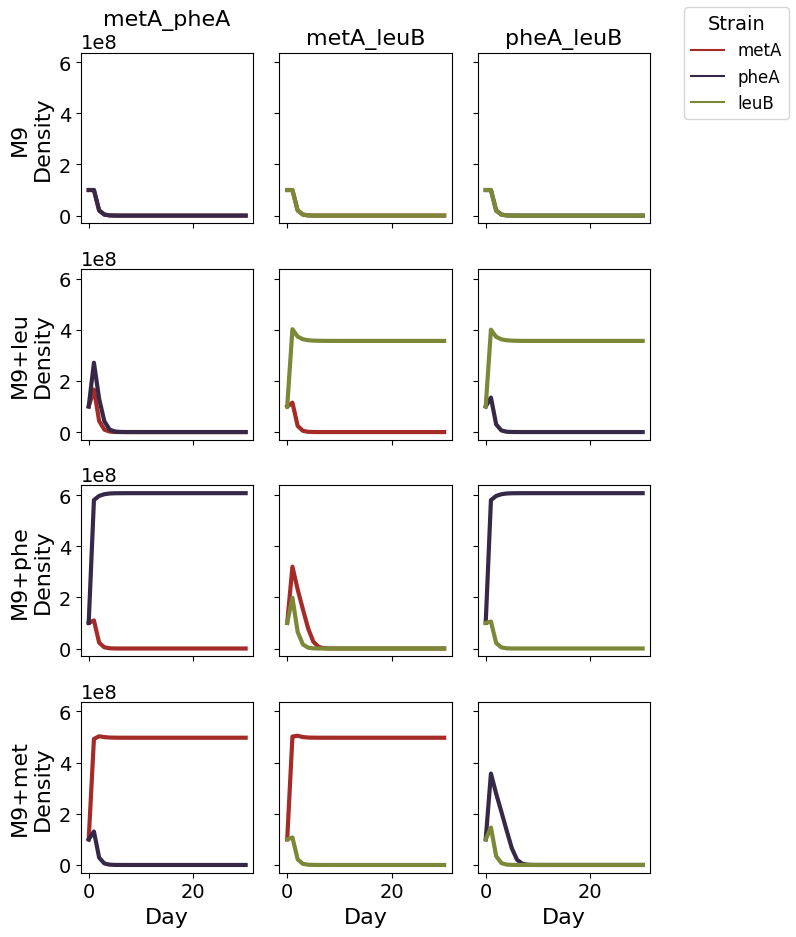

In [26]:

n_rows = len(media_values)
n_cols = len(pairs)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(2.75 * n_cols, 2. * n_rows),
    sharex=True,
    sharey=True
)

for i, media in enumerate(media_values):
    for j, pair_label in enumerate(pairs):
        ax = axes[i, j]

        record = pairwise_results[(pair_label, media)]
        resultsT_df = record["resultsT_df"]
        pair = record["pair"]
        active_indices = record["active_indices"]

        for strain, idx in zip(pair, active_indices):
            color = strain_color_map.get(strain, "black")

            ax.plot(
                resultsT_df["Time"] / 24,
                resultsT_df[f"X_{idx+1}"],
                linewidth=3,
                color=color,
                label=strain if (i == 0 and j == 0) else None
            )

        # Titles on top row
        if i == 0:
            ax.set_title(pair_label)

        # Row labels (media)
        if j == 0:
            ax.set_ylabel(f"{media}\nDensity")

        # X labels on bottom
        if i == n_rows - 1:
            ax.set_xlabel("Day")


handles = [
    mlines.Line2D([], [], color=strain_color_map[s], label=s)
    for s in legend_strains
]

fig.legend(
    handles=handles,
    loc="upper right",
    title="Strain"
)

plt.tight_layout(rect=[0, 0, 0.85, 1.2])

plt.savefig(figures_path / "model-pairwise_singleAA.pdf", dpi=300, bbox_inches="tight")
plt.show()

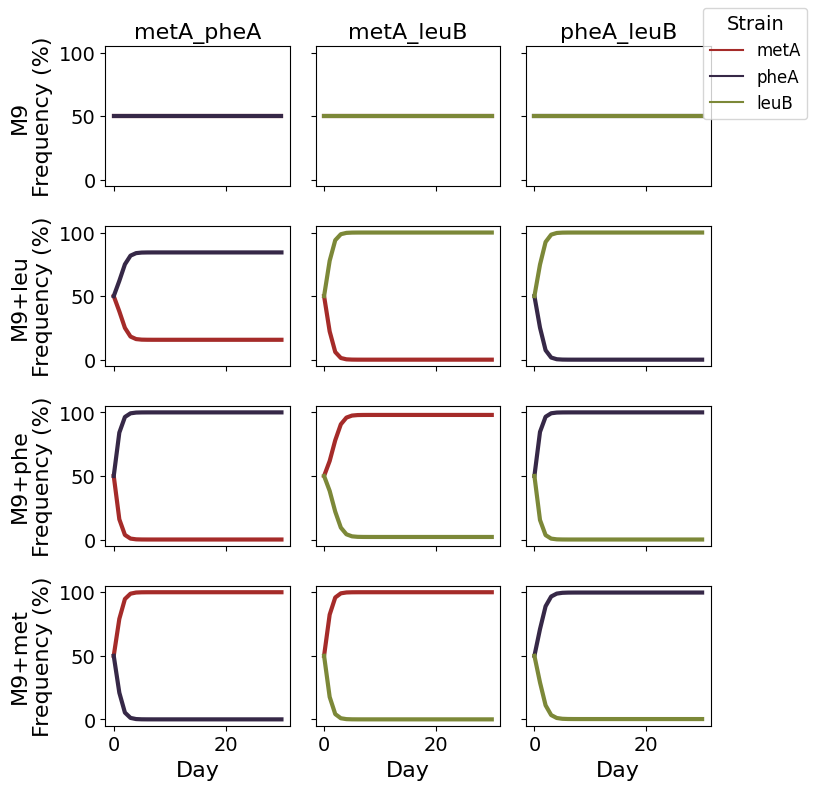

In [27]:


n_rows = len(media_values)
n_cols = len(pairs)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(2.75 * n_cols, 2. * n_rows),
    sharex=True,
    sharey=True
)

for i, media in enumerate(media_values):
    for j, pair_label in enumerate(pairs):
        ax = axes[i, j]

        record = pairwise_results[(pair_label, media)]
        resultsT_df = record["resultsT_df"]
        pair = record["pair"]
        active_indices = record["active_indices"]

        density_cols = [f"X_{idx+1}" for idx in active_indices]
        total_density = resultsT_df[density_cols].sum(axis=1)

        for strain, idx in zip(pair, active_indices):
            freq = np.where(
                total_density > 0,
                resultsT_df[f"X_{idx+1}"] / total_density * 100,
                np.nan
            )

            color = strain_color_map.get(strain, "black")

            ax.plot(
                resultsT_df["Time"] / 24,
                freq,
                linewidth=3,
                color=color,
                label=strain if (i == 0 and j == 0) else None  # single legend
            )

        ax.set_ylim(0, 100)

        # Titles only on top row
        if i == 0:
            ax.set_title(pair_label)

        # Row labels (media) on left
        if j == 0:
            ax.set_ylabel(f"{media}\nFrequency (%)")

        # X label only on bottom row
        if i == n_rows - 1:
            ax.set_xlabel("Day")

handles = [
    mlines.Line2D([], [], color=strain_color_map[s], label=s)
    for s in legend_strains
]

fig.legend(
    handles=handles,
    loc="upper right",
    title="Strain"
)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.ylim(-5, 105)
plt.savefig(figures_path / "model-pairwise_singleAA_freq.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [28]:
pairwise_summary_rows = []

for (pair_label, media), record in pairwise_results.items():
    resultsT_df = record["resultsT_df"]
    active_indices = record["active_indices"]

    final_row = resultsT_df.iloc[-1]
    endpoint_densities = np.array([
        final_row[f"X_{idx+1}"] for idx in active_indices
    ])

    outcome = classify_endpoint_outcome(endpoint_densities, ODmin=1e6)
    richness = np.sum(endpoint_densities > 1e6)

    pairwise_summary_rows.append({
        "pair": pair_label,
        "media": media,
        "outcome": outcome,
        "richness": richness,
        "total_density": endpoint_densities.sum()
    })

pairwise_summary_df = pd.DataFrame(pairwise_summary_rows)
print(pairwise_summary_df)


         pair   media                outcome  richness  total_density
0   metA_pheA      M9               collapse         0   1.073742e-12
1   metA_pheA  M9+leu               collapse         0   8.103551e-12
2   metA_pheA  M9+phe  competitive_exclusion         1   6.072445e+08
3   metA_pheA  M9+met  competitive_exclusion         1   4.973586e+08
4   metA_leuB      M9               collapse         0   1.073742e-12
5   metA_leuB  M9+leu  competitive_exclusion         1   3.562859e+08
6   metA_leuB  M9+phe               collapse         0   1.135233e-10
7   metA_leuB  M9+met  competitive_exclusion         1   4.973586e+08
8   pheA_leuB      M9               collapse         0   1.073742e-12
9   pheA_leuB  M9+leu  competitive_exclusion         1   3.562859e+08
10  pheA_leuB  M9+phe  competitive_exclusion         1   6.072445e+08
11  pheA_leuB  M9+met               collapse         0   4.025393e-10


Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-pairwise-outcome.pdf


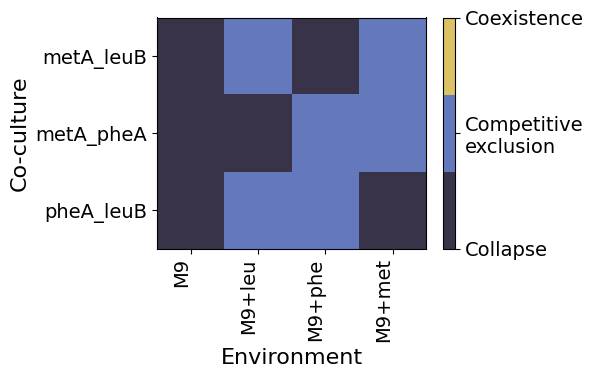

In [29]:
from matplotlib.colors import ListedColormap

outcome_order = {
    "collapse": 0,
    "competitive_exclusion": 1,
    "coexistence": 2
}

pairwise_summary_df["outcome_code"] = (
    pairwise_summary_df["outcome"]
    .map(outcome_order)
)

pivot = pairwise_summary_df.pivot(
    index="pair",
    columns="media",
    values="outcome_code"
)

media_order = ["M9", "M9+leu", "M9+phe", "M9+met"]
pivot = pivot[media_order]

# Use OUTCOME_COLORS consistently
outcome_cmap = ListedColormap([
    OUTCOME_COLORS["collapse"],
    OUTCOME_COLORS["competitive_exclusion"],
    OUTCOME_COLORS["coexistence"]
])

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(
    pivot.values,
    aspect="auto",
    vmin=0,
    vmax=2,
    cmap=outcome_cmap
)

ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(
    pivot.columns,
    rotation=90,
    ha="right"
)

ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index)

cbar = fig.colorbar(im, ticks=[0, 1, 2])

cbar.ax.set_yticklabels([
    "Collapse",
    "Competitive\nexclusion",
    "Coexistence"
])

ax.set_xlabel("Environment", fontsize=16)
ax.set_ylabel("Co-culture", fontsize=16)

plt.tight_layout()

outfile = figures_path / "model-constant-pairwise-outcome.pdf"
print(f"Exporting to {outfile}")

plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

## Constant: Dose-response (7 strains)

In [30]:
constant_doses = np.arange(0.1, 12.1, 0.1)



Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-simulation_12.0.pdf


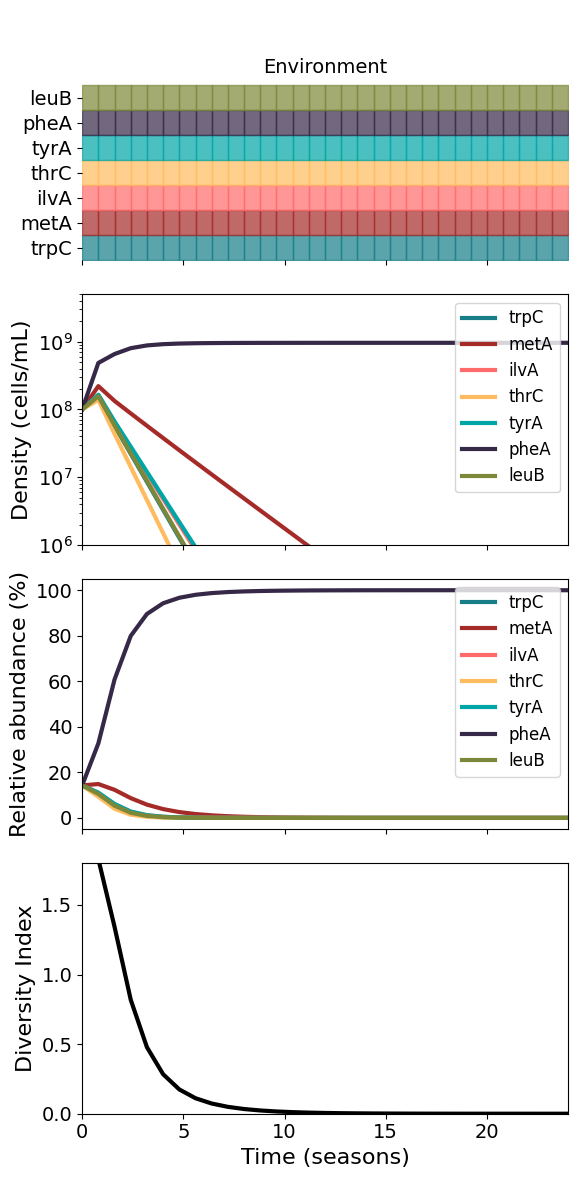

           strategy  dose  fitness_value  diversity_auc   density_auc  \
0     constant_0.10   0.1     108.274623     157.868061  3.229334e+11   
1     constant_0.20   0.2     126.687061     163.513833  4.238393e+11   
2     constant_0.30   0.3     139.765701     171.518053  4.682248e+11   
3     constant_0.40   0.4     150.065814     179.132593  4.960373e+11   
4     constant_0.50   0.5     159.018681     186.173854  5.163412e+11   
..              ...   ...            ...            ...           ...   
115  constant_11.60  11.6     166.950351     150.764787  7.074623e+11   
116  constant_11.70  11.7     166.788775     150.541475  7.078746e+11   
117  constant_11.80  11.8     166.629533     150.321391  7.082836e+11   
118  constant_11.90  11.9     166.472573     150.104463  7.086891e+11   
119  constant_12.00  12.0     166.317844     149.890619  7.090913e+11   

     endpoint_density  endpoint_shannon  richness                outcome  
0        4.224505e+08      3.998782e-09         

In [31]:

constant_rows = []

for dose in constant_doses:
    env_constant = [dose * np.ones(num_strains) for _ in range(N)]

    results_constant_df, resultsT_constant_df = run_simulation(
        strains_parameters, u0, env_constant, T
    )

    constant_record = add_reference(
        references=references,
        name=f"constant_{dose:.2f}",
        environment=env_constant,
        results_df=results_constant_df,
        resultsT_df=resultsT_constant_df,
        extra={"dose": dose}
    )

    constant_rows.append({
        "strategy": f"constant_{dose:.2f}",
        "dose": dose,
        "fitness_value": constant_record["fitness_value"],
        "diversity_auc": constant_record["diversity_auc"],
        "density_auc": constant_record["density_auc"],
        "endpoint_density": constant_record["endpoint_density"],
        "endpoint_shannon": constant_record["endpoint_shannon"],
        "richness": constant_record["richness"],
        "outcome": constant_record["outcome"],
    })

if dose ==constant_doses[-1]:
    plot_simulation(strains_parameters, resultsT_constant_df, N, env_constant)

    outfile = figures_path / f"model-constant-simulation_{dose}.pdf"
    print(f"Exporting to {outfile}")

    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()

constant_summary_df = pd.DataFrame(constant_rows)
print(constant_summary_df)

In [32]:
def plot_constant_dose_response(constant_summary_df, metric="fitness_value"):
    df = constant_summary_df.sort_values("dose").copy()

    plt.figure(figsize=(6, 4))

    if metric == "outcome":
        outcome_to_y = {
            "collapse": 0,
            "competitive_exclusion": 1,
            "coexistence": 2,
        }

        y_to_outcome = {v: k for k, v in outcome_to_y.items()}

        df["outcome_numeric"] = df["outcome"].map(outcome_to_y)

        plt.plot(
            df["dose"],
            df["outcome_numeric"],
            'k',
            linewidth=3,
        )

        plt.yticks(
            list(y_to_outcome.keys()),
            list(y_to_outcome.values())
        )

        plt.ylabel("Endpoint outcome")

    else:
        plt.plot(
            df["dose"],
            df[metric],
            'k',
            linewidth=3
        )

        plt.ylabel(metric)

    plt.xlabel("Dose ")
    plt.title(f"Constant dose-response: {metric}")
    plt.tight_layout()

    #outfile = figures_path / f"model-constant-simulation_{metric}.pdf"
    #print("Exporting to %s"%(outfile))
    #plt.savefig(outfile, dpi=300, bbox_inches="tight")

    #plt.show()

Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-dr-fitness_value.pdf


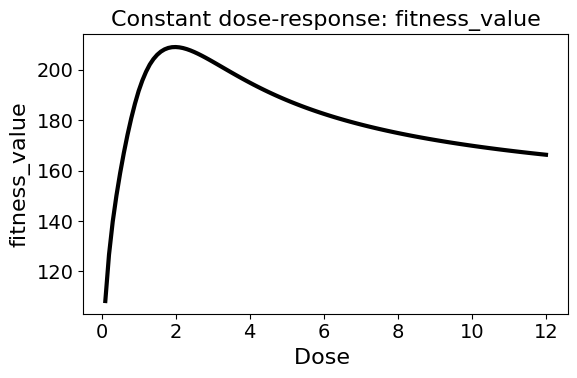

Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-dr-diversity_auc.pdf


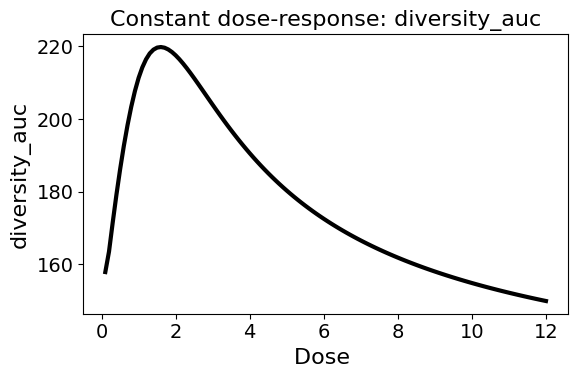

Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-dr-density_auc.pdf


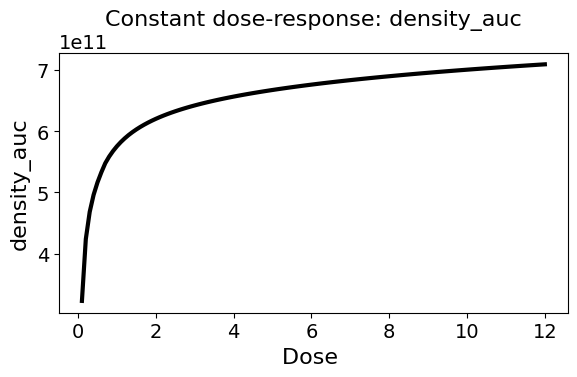

Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-dr-richness.pdf


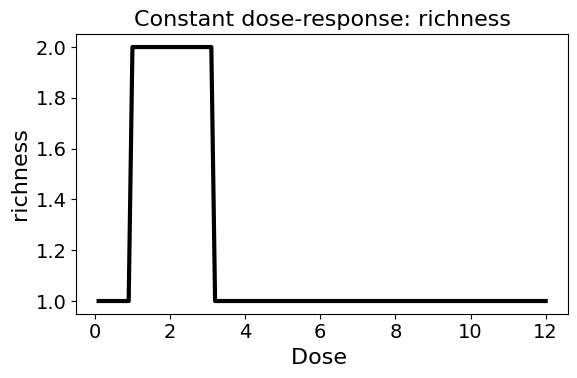

In [33]:
for metric in metrics:
    plot_constant_dose_response(constant_summary_df, metric=metric)

    outfile = figures_path / f"model-constant-dr-{metric}.pdf"
    print(f"Exporting to {outfile}")

    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()

## Constant: community combinatorics

In [34]:

dose_values = [0, 0.5, 1, 4, 16]

In [35]:
def simulate_constant_subsets_for_dose(
    this_dose,
    strains_parameters,
    u0,
    N,
    T,
    output_dir,
    min_subset_size=1,
    force=False
):
    output_dir.mkdir(parents=True, exist_ok=True)

    output_file = output_dir / f"subset_constant_dose_{this_dose:.2f}.pkl"

    if output_file.exists() and not force:
        print(f"Loading existing file: {output_file}")
        return pd.read_pickle(output_file)

    subset_constant_references = {}

    num_strains = len(strains_parameters)
    all_indices = list(range(num_strains))

    total_subsets = sum([
        len(list(combinations(all_indices, k)))
        for k in range(min_subset_size, num_strains + 1)
    ])

    counter = 0

    print(f"\n==============================")
    print(f"Constant dose: {this_dose:.2f}")
    print(f"==============================")

    for subset_size in range(min_subset_size, num_strains + 1):
        print(f"\n=== Subset size: {subset_size} ===")

        for active_indices in combinations(all_indices, subset_size):
            counter += 1
            active_indices = list(active_indices)

            active_strains = [strains_parameters[j]["name"] for j in active_indices]
            subset_label = "_".join([s[-4:] for s in active_strains])

            ref_name = f"constant_{this_dose:.2f}_subset_{subset_size}_{subset_label}"

            print(f"\n[{counter}/{total_subsets}] {ref_name}")
            print(f"Active strains: {active_strains}")

            u0_subset = make_subset_u0(
                u0=u0,
                active_indices=active_indices,
                num_strains=num_strains
            )

            env_constant = [this_dose * np.ones(num_strains) for _ in range(N)]

            results_df, resultsT_df = run_simulation(
                strains_parameters,
                u0_subset,
                env_constant,
                T
            )

            record = add_reference(
                references=subset_constant_references,
                name=ref_name,
                environment=env_constant,
                results_df=results_df,
                resultsT_df=resultsT_df,
                extra={
                    "subset_size": subset_size,
                    "active_indices": active_indices,
                    "active_strains": active_strains,
                    "dose": this_dose,
                }
            )

            endpoint_density = sum(
                record.get(f"final_density_X_{i+1}", 0)
                for i in range(num_strains)
            )

            print(
                f"Fitness={record['fitness_value']:.3g}, "
                f"Diversity={record['diversity_auc']:.3g}, "
                f"Density AUC={record['density_auc']:.3g}, "
                f"Endpoint density={endpoint_density:.3g}, "
                f"Richness={record['richness']}, "
                f"Outcome={record['outcome']}"
            )

    subset_constant_summary_df = build_reference_summary(subset_constant_references)
    subset_constant_summary_df["dose"] = this_dose

    subset_constant_summary_df.to_pickle(output_file)

    print(f"\nSaved subset constant summary to {output_file}")
    print(subset_constant_summary_df.head())

    return subset_constant_summary_df

In [36]:
subset_constant_path = feedback_path / "constant_subsets"


all_subset_constant_summaries = []

for this_dose in dose_values:
    df_dose = simulate_constant_subsets_for_dose(
        this_dose=this_dose,
        strains_parameters=strains_parameters,
        u0=u0,
        N=N,
        T=T,
        output_dir=subset_constant_path,
        min_subset_size=1,
        force=True
    )

    all_subset_constant_summaries.append(df_dose)

subset_constant_summary_all_df = pd.concat(
    all_subset_constant_summaries,
    ignore_index=True
)

subset_constant_summary_all_path = subset_constant_path / "subset_constant_summary_all_doses.pkl"
subset_constant_summary_all_df.to_pickle(subset_constant_summary_all_path)

print(f"Saved combined summary to {subset_constant_summary_all_path}")


Constant dose: 0.00

=== Subset size: 1 ===

[1/127] constant_0.00_subset_1_trpC
Active strains: ['M9_1X_trpC']
Fitness=16.3, Diversity=23.4, Density AUC=1.14e+10, Endpoint density=5.37e-13, Richness=0, Outcome=collapse

[2/127] constant_0.00_subset_1_metA
Active strains: ['M9_1X_metA']
Fitness=16.3, Diversity=23.4, Density AUC=1.14e+10, Endpoint density=5.37e-13, Richness=0, Outcome=collapse

[3/127] constant_0.00_subset_1_ilvA
Active strains: ['M9_1X_ilvA']
Fitness=16.3, Diversity=23.4, Density AUC=1.14e+10, Endpoint density=5.37e-13, Richness=0, Outcome=collapse

[4/127] constant_0.00_subset_1_thrC
Active strains: ['M9_1X_thrC']
Fitness=16.3, Diversity=23.4, Density AUC=1.14e+10, Endpoint density=5.37e-13, Richness=0, Outcome=collapse

[5/127] constant_0.00_subset_1_tyrA
Active strains: ['M9_1X_tyrA']
Fitness=16.3, Diversity=23.4, Density AUC=1.14e+10, Endpoint density=5.37e-13, Richness=0, Outcome=collapse

[6/127] constant_0.00_subset_1_pheA
Active strains: ['M9_1X_pheA']
Fitness

In [37]:
all_dfs = []

for this_dose in dose_values:
    df = simulate_constant_subsets_for_dose(
        this_dose=this_dose,
        strains_parameters=strains_parameters,
        u0=u0,
        N=N,
        T=T,
        output_dir=subset_constant_path,
        min_subset_size=2,
        force=False
    )
    all_dfs.append(df)

subset_constant_summary_all_df = pd.concat(all_dfs, ignore_index=True)

Loading existing file: /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/runs_local/feedback/constant_subsets/subset_constant_dose_0.00.pkl
Loading existing file: /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/runs_local/feedback/constant_subsets/subset_constant_dose_0.50.pkl
Loading existing file: /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/runs_local/feedback/constant_subsets/subset_constant_dose_1.00.pkl
Loading existing file: /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/runs_local/feedback/constant_subsets/subset_constant_dose_4.00.pkl
Loading existing file: /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/runs_local/feedback/constant_subsets/subset_constant_dose_16.00.pkl


In [38]:
def format_metric_label(metric):
    label = metric.replace("_", " ")

    # capitalize first word
    words = label.split()
    if words:
        words[0] = words[0].capitalize()

    # force AUC capitalization
    words = [w.upper() if w.lower() == "auc" else w for w in words]

    return " ".join(words)

def plot_metric_vs_dose(
    subset_constant_summary_df,
    metric="fitness_value",
    cmap_name="cividis_r"
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    df = subset_constant_summary_df.dropna(subset=[metric])

    sizes = sorted(df["subset_size"].unique())
    cmap = plt.get_cmap(cmap_name)

    colors = {
        size: cmap(i / (len(sizes) - 1) if len(sizes) > 1 else 0.5)
        for i, size in enumerate(sizes)
    }

    fig, ax = plt.subplots(figsize=(6, 4))

    for size in sizes:
        df_s = df[df["subset_size"] == size]

        summary = (
            df_s
            .groupby("dose")[metric]
            .agg(["mean", "std", "count"])
            .reset_index()
        )
        summary["sem"] = summary["std"] / np.sqrt(summary["count"])

        ax.errorbar(
            summary["dose"],
            summary["mean"],
            yerr=summary["sem"],
            marker="o",
            capsize=4,
            color=colors[size]
        )

    ax.set_xlabel("Supplemented amino acid level\n(× basal concentration)")
    ax.set_ylabel(format_metric_label(metric))
    norm = mpl.colors.Normalize(vmin=min(sizes), vmax=max(sizes))
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    fig.colorbar(sm, ax=ax, label="Community size")

    plt.tight_layout()
    #plt.show()

Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-dr-AA-fitness_value.pdf


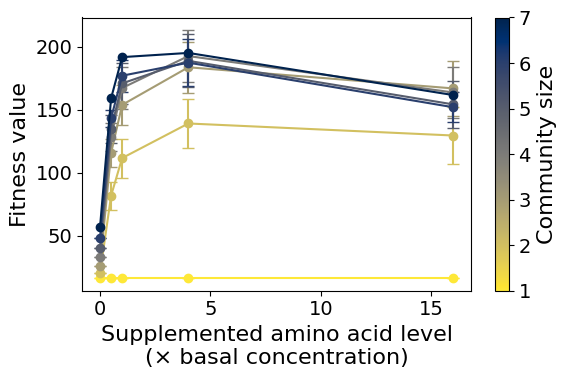

Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-dr-AA-diversity_auc.pdf


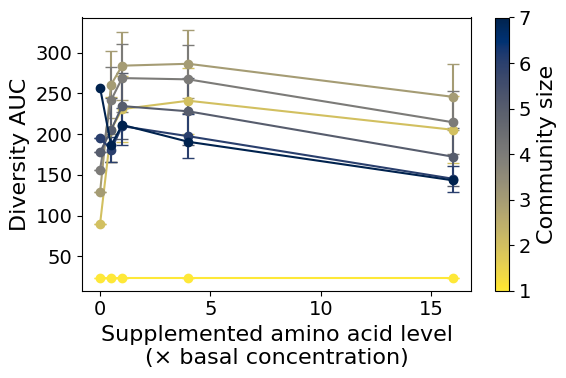

Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-dr-AA-density_auc.pdf


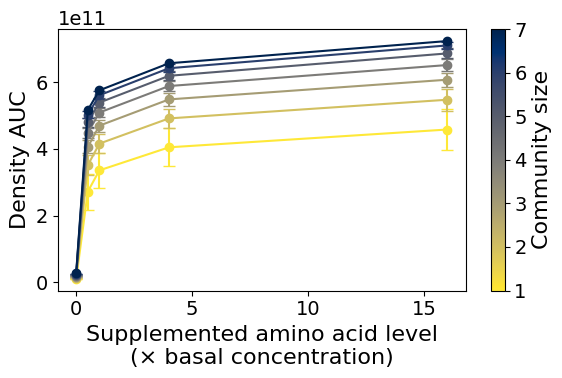

Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-dr-AA-richness.pdf


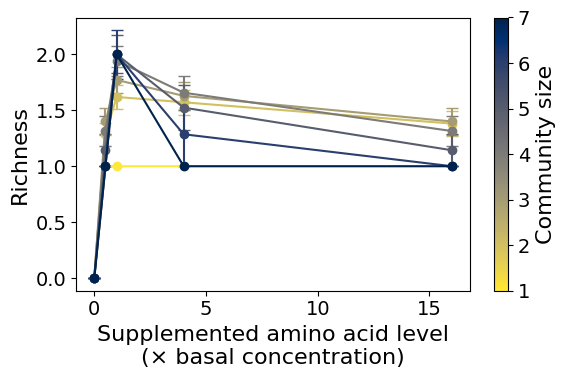

In [39]:


for metric in metrics:
    plot_metric_vs_dose(
        subset_constant_summary_all_df,
        metric=metric
    )

    outfile = figures_path / f"model-constant-dr-AA-{metric}.pdf"
    print(f"Exporting to {outfile}")
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()

In [40]:
def plot_outcome_fractions_by_dose(df):
    import pandas as pd
    import matplotlib.pyplot as plt

    outcome_order = ["collapse", "competitive_exclusion", "coexistence"]

    counts = pd.crosstab(
        df["dose"],
        df["outcome"],
        normalize="index"
    )

    counts = counts.reindex(columns=outcome_order, fill_value=0)
    counts = counts.sort_index()

    # Convert to %
    counts = counts * 100

    ax = counts.plot(
        kind="bar",
        stacked=True,
        figsize=(7, 4),
        width=0.85,
        color=[OUTCOME_COLORS[o] for o in outcome_order]
    )

    ax.set_xlabel("Supplemented amino acid level\n(× basal concentration)")
    ax.set_ylabel("Simulations (%)")

    ax.set_ylim(0, 105)

    ax.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()
    #plt.show()

Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-dr-outcome.pdf


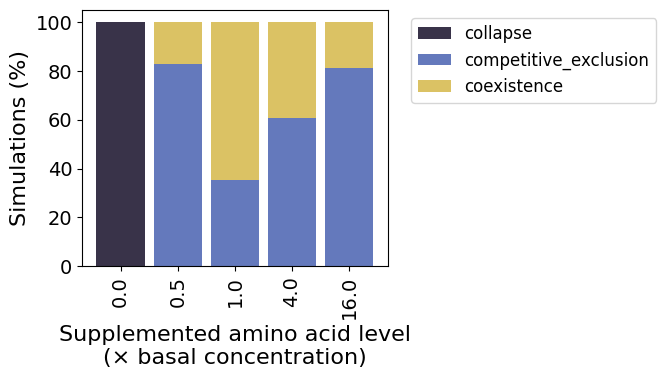

In [41]:
plot_outcome_fractions_by_dose(subset_constant_summary_all_df)

outfile = figures_path / f"model-constant-dr-outcome.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

In [42]:
def plot_subset_metric_constant(
    subset_constant_summary_df,
    metric="fitness_value",
    cmap_name="cividis_r"
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    const = subset_constant_summary_df.dropna(subset=[metric])

    doses = sorted(const["dose"].dropna().unique())
    cmap = plt.get_cmap(cmap_name)

    colors = {
        dose: cmap(i / (len(doses) - 1) if len(doses) > 1 else 0.5)
        for i, dose in enumerate(doses)
    }

    fig, ax = plt.subplots(figsize=(6, 3.6))

    for dose in doses:
        const_d = const[const["dose"] == dose]

        const_summary = (
            const_d
            .groupby("subset_size")[metric]
            .agg(["mean", "std", "count"])
            .reset_index()
        )

        const_summary["sem"] = (
            const_summary["std"] / np.sqrt(const_summary["count"])
        )

        ax.errorbar(
            const_summary["subset_size"],
            const_summary["mean"],
            yerr=const_summary["sem"],
            marker="o",
            capsize=4,
            color=colors[dose]
        )

    ax.set_xlabel("Community size")
    ax.set_ylabel(format_metric_label(metric))
    ax.set_xticks(sorted(const["subset_size"].unique()))

    norm = mpl.colors.Normalize(vmin=min(doses), vmax=max(doses))
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    fig.colorbar(
        sm,
        ax=ax,
        label="Supplemented amino acid\n(× basal concentration)"
    )

    plt.tight_layout()
    #plt.show()

Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-dr-size-fitness_value.pdf


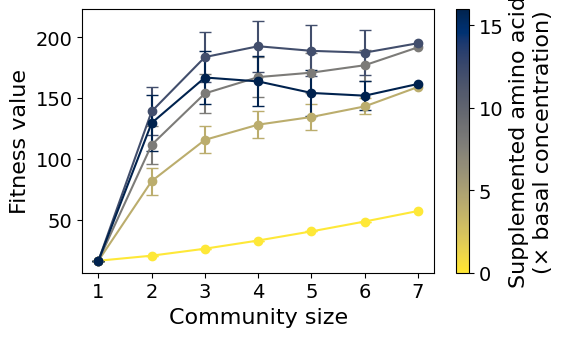

Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-dr-size-diversity_auc.pdf


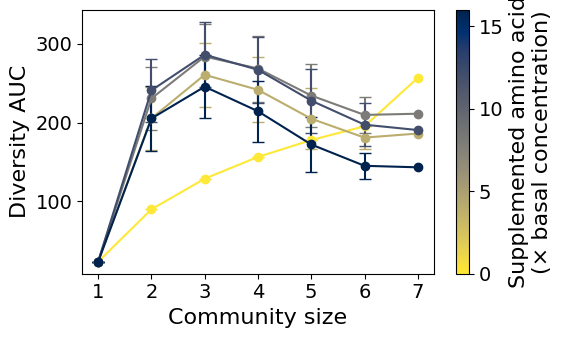

Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-dr-size-density_auc.pdf


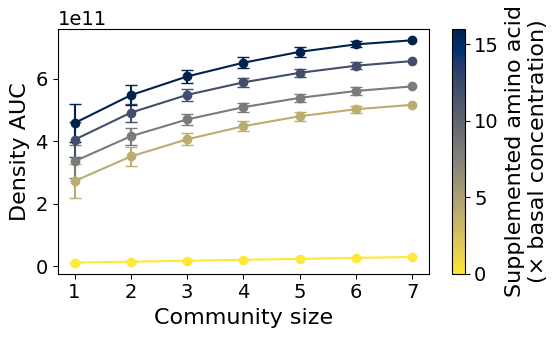

Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-dr-size-richness.pdf


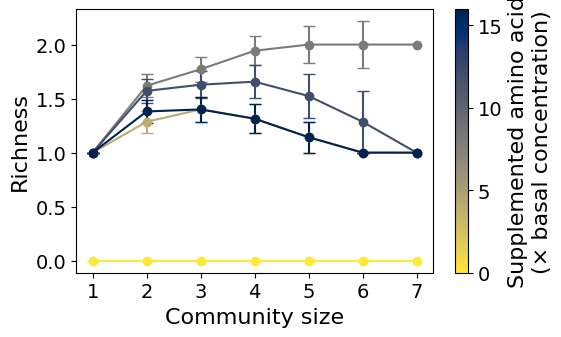

In [43]:
metrics = ["fitness_value", "diversity_auc", "density_auc", "richness"]

for metric in metrics:
    plot_subset_metric_constant(
        subset_constant_summary_all_df,
        metric=metric
    )

    outfile = figures_path / f"model-constant-dr-size-{metric}.pdf"
    print(f"Exporting to {outfile}")
    plt.savefig(outfile, dpi=300)
    plt.show()

In [44]:
def plot_outcome_fractions_by_size(subset_summary_df, dose=None):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    df = subset_summary_df.copy()

    if dose is not None:
        df = df[np.isclose(df["dose"], dose)]

    if len(df) == 0:
        print("No rows found after filtering.")
        print("Available doses:")
        print(sorted(subset_summary_df["dose"].dropna().unique()))
        return

    outcome_order = ["collapse", "competitive_exclusion", "coexistence"]

    counts = pd.crosstab(
        df["subset_size"],
        df["outcome"],
        normalize="index"
    )

    counts = counts.reindex(columns=outcome_order, fill_value=0)

    # Convert to %
    counts = counts * 100

    ax = counts.plot(
        kind="bar",
        stacked=True,
        figsize=(7, 4),
        width=0.8,
        color=[OUTCOME_COLORS[o] for o in outcome_order]
    )

    ax.set_xlabel("Community size", fontsize=16)
    ax.set_ylabel("Simulations (%)", fontsize=16)
    ax.set_ylim(0, 100)

    ax.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()
    #plt.show()


===== Dose = 0.00 =====
Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-aa-outcome-dose0.pdf

===== Dose = 0.50 =====
Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-aa-outcome-dose0p5.pdf

===== Dose = 1.00 =====
Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-aa-outcome-dose1.pdf

===== Dose = 4.00 =====
Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-aa-outcome-dose4.pdf

===== Dose = 16.00 =====
Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-constant-aa-outcome-dose16.pdf


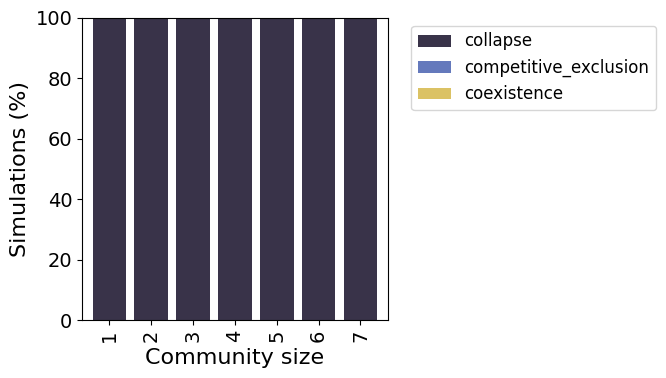

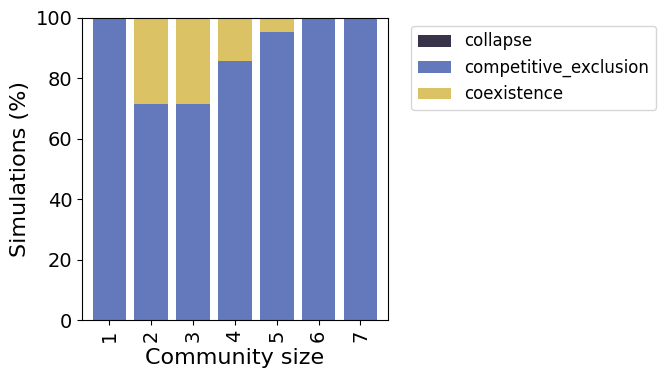

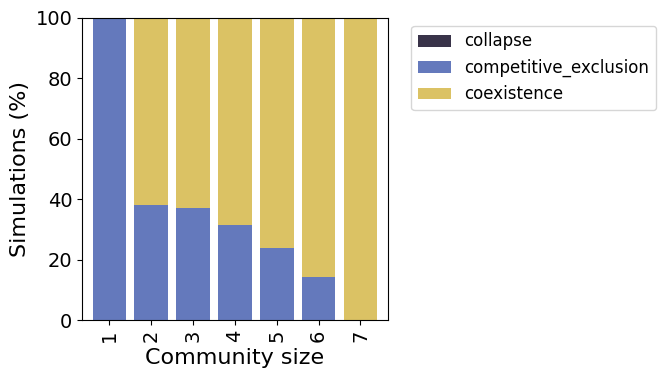

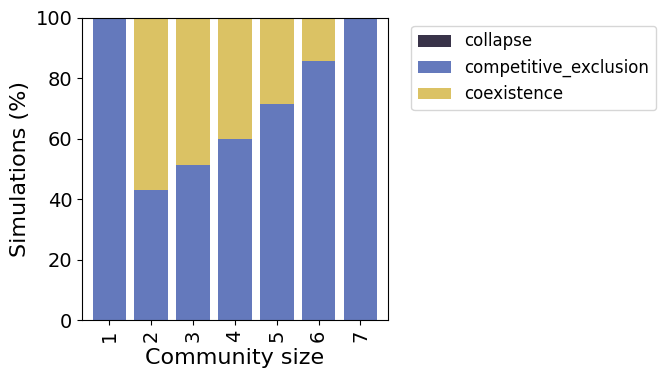

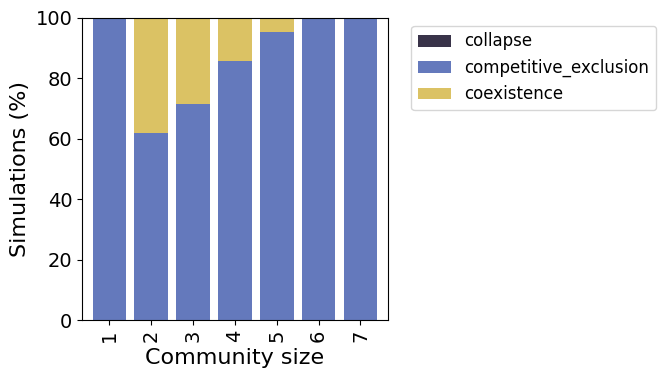

In [45]:

for this_dose in sorted(subset_constant_summary_all_df["dose"].unique()):
    print(f"\n===== Dose = {this_dose:.2f} =====")

    plot_outcome_fractions_by_size(
        subset_constant_summary_all_df,
        dose=this_dose
    )

    dose_str = f"{this_dose:.2f}".rstrip("0").rstrip(".")
    dose_str = dose_str.replace(".", "p")
    outfile = figures_path / f"model-constant-aa-outcome-dose{dose_str}.pdf"
    print(f"Exporting to {outfile}")
    plt.savefig(outfile, dpi=300, bbox_inches="tight")



---



In [46]:
#We use this Amax for the rest of the simulations
print("Amax=",Amax)
subset_constant_summary_df = subset_constant_summary_all_df[
    np.isclose(subset_constant_summary_all_df["dose"], Amax)
].copy()

Amax= 4


## Random

In [47]:

random_summary_path = random_path / "summary.pkl"

if random_summary_path.exists():
    random_summary_df = pd.read_pickle(random_summary_path)
    print(f"Loaded {len(random_summary_df)} existing random treatments")
else:
    random_summary_df = pd.DataFrame()
    print("No existing summary file found")

Loaded 10000 existing random treatments


In [48]:
existing_labels = set(random_summary_df["binary_label"]) if len(random_summary_df) > 0 else set()

n_existing = len(existing_labels)
n_to_add = max(0, sample_size - n_existing)

print(f"Existing unique treatments: {n_existing}")
print(f"Need to add: {n_to_add}")

Existing unique treatments: 10000
Need to add: 0


In [49]:
def run_random_treatment_summaries(
    strains_parameters,
    S0,
    Amax,
    B0,
    num_days,
    T,
    n_to_add,
    existing_labels,
    seed=42,
    target_densities=None,
    ODmin=1e6   # <-- add this
):
    rng = random.Random(seed)

    if existing_labels is None:
        existing_labels = set()

    num_strains = len(strains_parameters)
    u0 = [S0] + [Amax] * num_strains + [B0] * num_strains

    new_rows = []

    while len(new_rows) < n_to_add:
        # one binary decision per day and per amino acid
        binary_treatment_matrix = np.array([
            [rng.randint(0, 1) for _ in range(num_strains)]
            for _ in range(num_days)
        ], dtype=int)

        binary_label = binary_treatment_matrix.tobytes()

        if binary_label in existing_labels:
            continue

        existing_labels.add(binary_label)

        # each element must be a vector of length num_strains
        env_conditions = [
            (Amax * binary_treatment_matrix[day]).astype(float).tolist()
            for day in range(num_days)
        ]

        results_df, resultsT_df = run_simulation(
            strains_parameters,
            u0,
            env_conditions,
            T
        )

        fitness_value, diversity_auc, density_auc = fitness_function_diversity(resultsT_df)

        relative_proportion = calculate_relative_proportion(resultsT_df)
        endpoint = relative_proportion.iloc[-1]
        endpoint_shannon = shannon_diversity(endpoint.values)

        final_row = resultsT_df.iloc[-1]
        x_cols = [col for col in resultsT_df.columns if col.startswith("X_")]
        endpoint_densities = final_row[x_cols].values.astype(float)
        endpoint_density = np.sum(endpoint_densities)

        richness = np.sum(endpoint_densities > ODmin)
        outcome = classify_endpoint_outcome(endpoint_densities, ODmin=ODmin)

        row = {
            "binary_label": binary_label,
            "binary_treatment": binary_treatment_matrix.tolist(),
            "fitness_value": fitness_value,
            "fitness_weighted_shannon_auc": fitness_value,
            "diversity_auc": diversity_auc,
            "shannon_auc": diversity_auc,
            "density_auc": density_auc,
            "endpoint_density": endpoint_density,
            "endpoint_shannon": endpoint_shannon,
            "richness": richness,
            "outcome": outcome,
        }

        if target_densities is not None:
            row["fitness_target"] = fitness_function_target(results_df, target_densities)
        else:
            row["fitness_target"] = np.nan

        for strain_name, value in endpoint.items():
            row[f"final_prop_{strain_name}"] = value

        new_rows.append(row)
        if len(new_rows) % 100 == 0:
          print(".", end="")
          if len(new_rows) % 1000 == 0:
            print("")

    print()
    return pd.DataFrame(new_rows)

In [50]:
new_rows_df = run_random_treatment_summaries(
    strains_parameters=strains_parameters,
    S0=S0,
    Amax=Amax,
    B0=B0,
    num_days=N,
    T=T,
    n_to_add=n_to_add,
    existing_labels=existing_labels,
    seed=42,
    target_densities=None
)

random_summary_df = pd.concat([random_summary_df, new_rows_df], ignore_index=True)
random_summary_df.to_pickle(random_summary_path)

if "fitness_value" not in random_summary_df.columns and "fitness_weighted_shannon_auc" in random_summary_df.columns:
    random_summary_df["fitness_value"] = random_summary_df["fitness_weighted_shannon_auc"]

if "diversity_auc" not in random_summary_df.columns and "shannon_auc" in random_summary_df.columns:
    random_summary_df["diversity_auc"] = random_summary_df["shannon_auc"]

print(f"Saved updated summary with {len(random_summary_df)} treatments to {random_summary_path}")


Saved updated summary with 10000 treatments to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/runs_local/random/summary.pkl


In [51]:
def print_random_summary_statistics(random_summary_df):
    print("\n=== Random Treatment Summary ===\n")

    cols = [
        "fitness_value",
        "shannon_auc",
        "density_auc",
        "endpoint_shannon"
    ]

    for col in cols:
        values = random_summary_df[col].dropna()

        print(f"{col}:")
        print(f"  mean ± std: {values.mean():.4f} ± {values.std():.4f}")
        print(f"  median:     {values.median():.4f}")
        print(f"  5–95%:      {values.quantile(0.05):.4f} – {values.quantile(0.95):.4f}")
        print(f"  min / max:  {values.min():.4f} / {values.max():.4f}")
        print()
print_random_summary_statistics(random_summary_df)


=== Random Treatment Summary ===

fitness_value:
  mean ± std: 264.1523 ± 69.9963
  median:     263.4883
  5–95%:      152.4528 – 380.7982
  min / max:  87.0132 / 511.1858

shannon_auc:
  mean ± std: 341.3782 ± 106.6202
  median:     336.9928
  5–95%:      175.6327 – 523.2233
  min / max:  98.8150 / 754.1841

density_auc:
  mean ± std: 532047205086.0120 ± 30006809796.7988
  median:     535287732274.6517
  5–95%:      477021612631.6721 – 575048119197.9604
  min / max:  379323643200.2264 / 615432220933.0422

endpoint_shannon:
  mean ± std: 0.1757 ± 0.2397
  median:     0.0360
  5–95%:      0.0000 – 0.6791
  min / max:  0.0000 / 1.2029



In [52]:
def select_random_environments(random_summary_df, mode="top", n=5, sort_by="fitness_value"):
    df = random_summary_df.dropna(subset=[sort_by]).copy()

    if mode == "top":
        selected = df.sort_values(sort_by, ascending=False).head(n)

    elif mode == "bottom":
        selected = df.sort_values(sort_by, ascending=True).head(n)

    elif mode == "median":
        df = df.copy()
        median_value = df[sort_by].median()
        df["distance_to_median"] = (df[sort_by] - median_value).abs()
        selected = df.sort_values("distance_to_median", ascending=True).head(n).drop(columns="distance_to_median")

    else:
        raise ValueError("mode must be 'top', 'bottom', or 'median'")

    return selected


def plot_selected_random(
    random_summary_df,
    strains_parameters,
    u0,
    Amax,
    num_days,
    T,
    mode="top",
    n=5,
    sort_by="fitness_value"
):
    selected_df = select_random_environments(
        random_summary_df=random_summary_df,
        mode=mode,
        n=n,
        sort_by=sort_by
    )

    selected_environments = []

    print(f"\n=== Plotting {mode} {n} random environments ({sort_by}) ===\n")

    for i, (_, row) in enumerate(selected_df.iterrows(), 1):
        env = [
            Amax * np.array(day_bits)
            for day_bits in row["binary_treatment"]
        ]

        selected_environments.append({
            "rank": i,
            "mode": mode,
            "sort_by": sort_by,
            "fitness_value": row.get("fitness_value", np.nan),
            "diversity_auc": row.get("diversity_auc", np.nan),
            "density_auc": row.get("density_auc", np.nan),
            "endpoint_shannon": row.get("endpoint_shannon", np.nan),
            "richness": row.get("richness", np.nan),
            "outcome": row.get("outcome", np.nan),
            "binary_treatment": row["binary_treatment"],
            "environment": env,
        })

        print(f"\n{mode.capitalize()} {i}: {sort_by}: {row[sort_by]:.4f}")

        results_df, resultsT_df = run_simulation(
            strains_parameters,
            u0,
            env,
            T
        )

        plot_simulation(
            strains_parameters,
            resultsT_df,
            num_days,
            env
        )

    return selected_df, selected_environments

def print_selected_random(random_summary_df, mode="top", n=5, sort_by="fitness_value"):
    selected_df = select_random_environments(
        random_summary_df=random_summary_df,
        mode=mode,
        n=n,
        sort_by=sort_by
    )

    print(f"\n=== {mode.capitalize()} {n} random environments ({sort_by}) ===\n")

    for i, (_, row) in enumerate(selected_df.iterrows(), 1):
        print(f"{i}: fitness: {row[sort_by]:.4f}")
        #print(f"  label: {row['binary_label']}")

In [53]:
print_selected_random(random_summary_df, mode="top", n=3)
print_selected_random(random_summary_df, mode="bottom", n=3)
print_selected_random(random_summary_df, mode="median", n=3)




=== Top 3 random environments (fitness_value) ===

1: fitness: 511.1858
2: fitness: 510.1633
3: fitness: 486.7966

=== Bottom 3 random environments (fitness_value) ===

1: fitness: 87.0132
2: fitness: 98.9311
3: fitness: 101.7301

=== Median 3 random environments (fitness_value) ===

1: fitness: 263.4841
2: fitness: 263.4926
3: fitness: 263.5116



=== Plotting median 1 random environments (fitness_value) ===


Median 1: fitness_value: 263.4841
Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-random-simulation_median.pdf

=== Plotting top 1 random environments (fitness_value) ===


Top 1: fitness_value: 511.1858
Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-random-simulation_top.pdf

=== Plotting bottom 1 random environments (fitness_value) ===


Bottom 1: fitness_value: 87.0132
Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-random-simulation_bottom.pdf


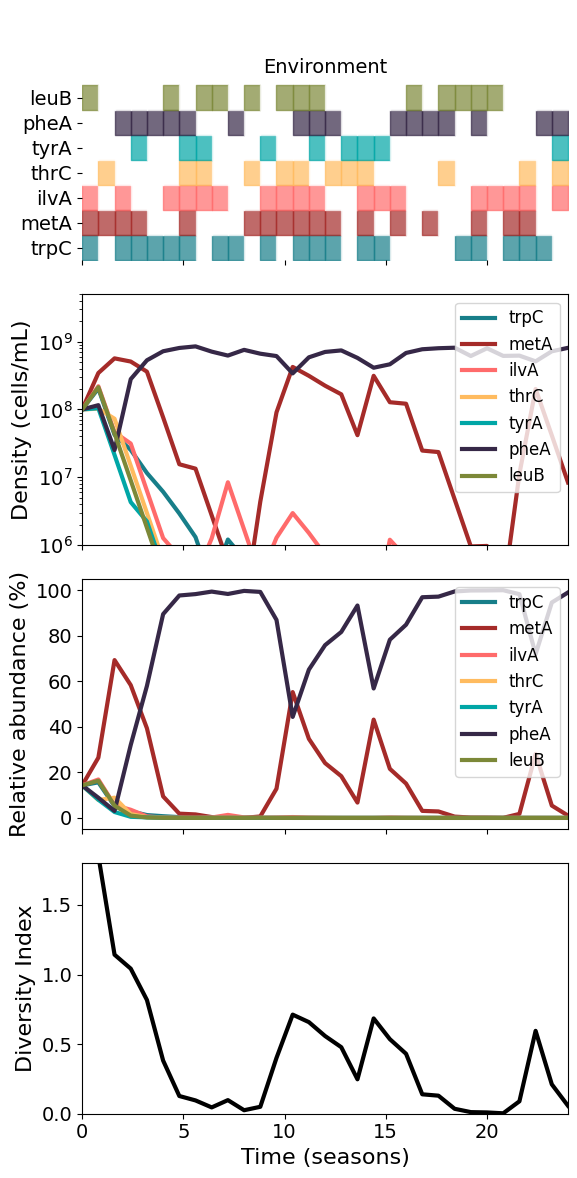

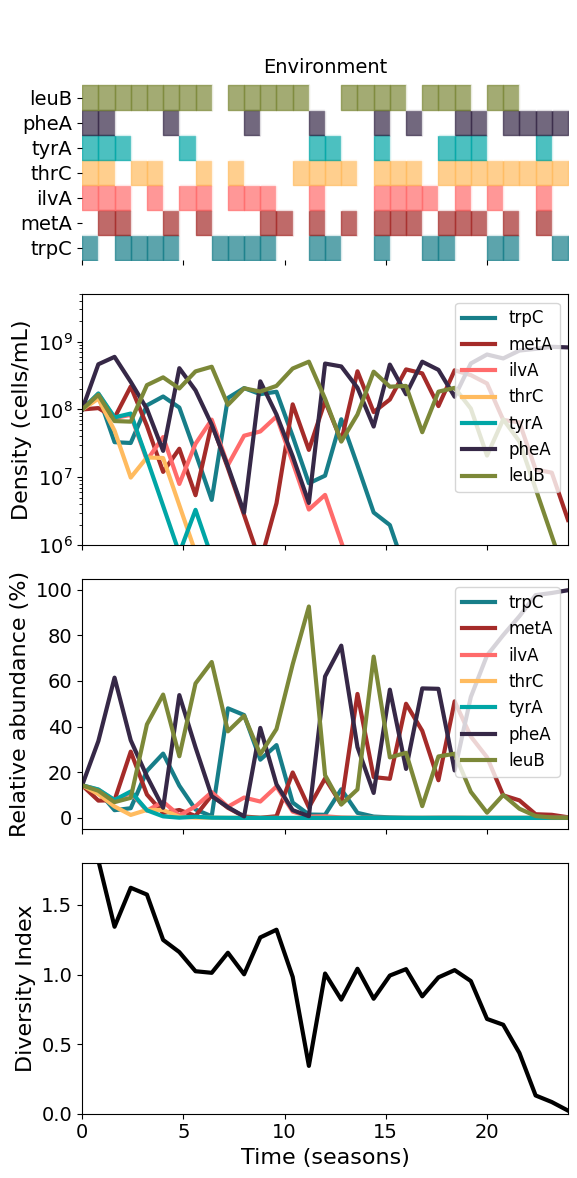

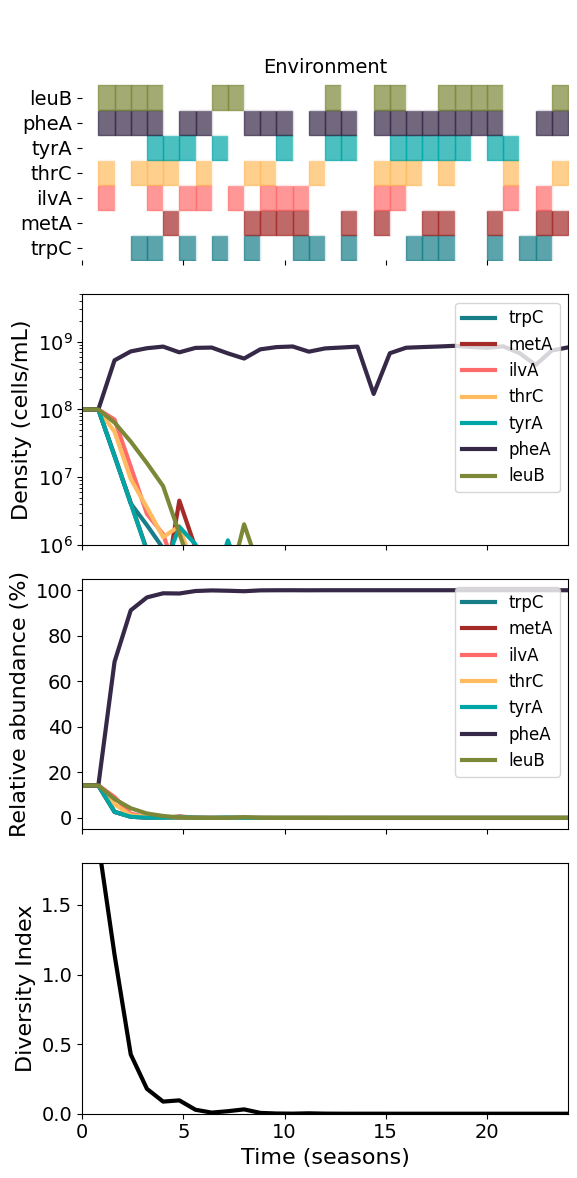

In [54]:

median_df, median_envs = plot_selected_random(
    random_summary_df,
    strains_parameters=strains_parameters,
    u0=u0,
    Amax=Amax,
    num_days=N,
    T=T,
    mode="median",
    n=1,
    sort_by="fitness_value"
)
outfile = figures_path / f"model-random-simulation_median.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300, bbox_inches="tight")

median_environment = median_envs[0]["environment"]

top_df, top_envs = plot_selected_random(
    random_summary_df,
    strains_parameters,
    u0,
    Amax,
    N,
    T,
    mode="top",
    n=1
)
outfile = figures_path / f"model-random-simulation_top.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300, bbox_inches="tight")

bottom_df, bottom_envs = plot_selected_random(
    random_summary_df,
    strains_parameters,
    u0,
    Amax,
    N,
    T,
    mode="bottom",
    n=1
)
outfile = figures_path / f"model-random-simulation_bottom.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300, bbox_inches="tight")



---
## Genetic algorithm


In [55]:
def genetic_algorithm(
    strains_parameters,
    T,
    initial_environment,
    num_generations=100,
    starting_generation=1,
    save_dir=None
):

    # Infer dimensions
    num_days = len(initial_environment)
    num_strains = len(initial_environment[0])

    # Initialize population
    population = initialize_population(POP_SIZE, num_days, num_strains, initial_environment)

    # Track fitness evolution
    best_fitness_per_gen = []
    mean_fitness_per_gen = []
    std_fitness_per_gen = []

    # Track best overall solution
    best_environment_overall = None
    best_fitness_overall = -np.inf
    best_diversity_auc_overall = np.nan
    best_density_auc_overall = np.nan
    best_generation_overall = None

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for gen in range(num_generations):
        generation_number = starting_generation + gen
        print(f"\n* Generation {generation_number}/{starting_generation + num_generations - 1}", end="")
        start = time.time()

        # Step 1: Evaluate Fitness
        fitness_results = [compute_fitness(strains_parameters, env, T, toPlot=False) for env in population]
        fitness_scores = [res[0] for res in fitness_results]

        # Debugging printout
        print(f"\n  -> Max fitness (best): {max(fitness_scores)}")
        print(f"  -> Mean fitness: {np.mean(fitness_scores)}")
        print(f"  -> Min fitness (worst): {min(fitness_scores)}")

        # Store fitness statistics
        best_fitness_this_gen = np.max(fitness_scores)
        mean_fitness_this_gen = np.mean(fitness_scores)
        std_fitness_this_gen = np.std(fitness_scores)

        best_fitness_per_gen.append(best_fitness_this_gen)
        mean_fitness_per_gen.append(mean_fitness_this_gen)
        std_fitness_per_gen.append(std_fitness_this_gen)

        # Identify best individual in current generation
        best_index = int(np.argmax(fitness_scores))
        best_env_this_gen = population[best_index]
        _, diversity_auc_this_gen, density_auc_this_gen = fitness_results[best_index]

        # Update best overall
        if best_fitness_this_gen > best_fitness_overall:
            best_environment_overall = best_env_this_gen
            best_fitness_overall = best_fitness_this_gen
            best_diversity_auc_overall = diversity_auc_this_gen
            best_density_auc_overall = density_auc_this_gen
            best_generation_overall = generation_number

        # Save checkpoint
        if save_dir is not None:
            fitness_record = {
                "generation": generation_number,
                "environment": best_env_this_gen,
                "best_fitness": best_fitness_this_gen,
                "mean_fitness": mean_fitness_this_gen,
                "std_fitness": std_fitness_this_gen,
                "diversity_auc": diversity_auc_this_gen,
                "density_auc": density_auc_this_gen,
            }

            save_path = os.path.join(save_dir, f"best_env_gen{generation_number}.pkl")
            with open(save_path, "wb") as f:
                pickle.dump(fitness_record, f)

        # Step 2: Select Parents
        num_offspring_needed = POP_SIZE - ELITE_SIZE
        num_parents_needed = num_offspring_needed
        if num_parents_needed % 2 != 0:
            num_parents_needed += 1

        parents = select_parents(population, fitness_scores, num_parents=num_parents_needed)

        # Step 3: Generate Offspring via Crossover
        offspring = []
        for i in range(0, len(parents), 2):
            if i + 1 < len(parents):
                child1, child2 = crossover_environments(
                    parents[i],
                    parents[i + 1],
                    CROSSOVER_RATE,
                    AA_CROSSOVER_RATE
                )
                offspring.append(child1)
                offspring.append(child2)

        # Step 4: Apply Mutation
        mutated_offspring = [
            mutate_environment(child, MUTATION_RATE, AA_MUTATION_RATE)
            for child in offspring
        ]

        # Step 5: Create Next Generation with elitism
        sorted_indices = np.argsort(fitness_scores)[::-1]
        sorted_population = [population[i] for i in sorted_indices]

        new_population = sorted_population[:ELITE_SIZE] + mutated_offspring[:POP_SIZE - ELITE_SIZE]
        population = new_population

        print(f"Fitness evaluation took {time.time() - start:.2f} seconds")

    return {
        "best_environment": best_environment_overall,
        "best_fitness": best_fitness_overall,
        "best_diversity_auc": best_diversity_auc_overall,
        "best_density_auc": best_density_auc_overall,
        "best_generation": best_generation_overall,
        "best_fitness_per_gen": best_fitness_per_gen,
        "mean_fitness_per_gen": mean_fitness_per_gen,
        "std_fitness_per_gen": std_fitness_per_gen,
    }

In [56]:


def mutate_environment(environment, mutation_rate=0.2, aa_mutation_rate=0.5, Amax=8):
    """
    Mutate the environmental conditions by flipping amino acid availability
    (from 0 to Amax or from Amax to 0) for selected days and amino acids.

    Parameters:
    - environment: List of amino acid conditions per cycle (each entry is a list for all strains).
    - mutation_rate: Fraction of days to mutate.
    - aa_mutation_rate: Fraction of amino acids to mutate per selected day.
    - Amax: Maximum concentration to toggle to (default = 8).

    Returns:
    - mutated_environment: Mutated version of the environment list.
    """

    mutated_environment = [list(day) for day in environment]  # Deep copy

    num_days = len(environment)
    num_aa = len(environment[0])
    num_mutations = max(1, int(mutation_rate * num_days))

    mutation_indices = random.sample(range(num_days), num_mutations)

    for day_idx in mutation_indices:
        aa_indices = random.sample(range(num_aa), max(1, int(aa_mutation_rate * num_aa)))
        for aa_idx in aa_indices:
            # Flip amino acid: 0 -> Amax, Amax -> 0
            current = mutated_environment[day_idx][aa_idx]
            mutated_environment[day_idx][aa_idx] = 0 if current > 0 else Amax

    return mutated_environment



def crossover_environments(parent1, parent2, crossover_rate=0.5, aa_crossover_rate=0.5):
    """
    Performs crossover between two parent environments, ensuring that amino acids
    from both parents are combined while maintaining diversity in different days.

    Parameters:
    - parent1: First parent environment (list of lists).
    - parent2: Second parent environment (list of lists).
    - crossover_rate: Fraction of days that are mixed (default = 50%).
    - aa_crossover_rate: Fraction of amino acids that are swapped per mixed day (default = 50%).

    Returns:
    - child1, child2: Two new environments resulting from crossover.
    """

    # Ensure both parents have the same number of days and amino acids
    assert len(parent1) == len(parent2), "Parent environments must have the same length."
    num_days = len(parent1)
    num_aa = len(parent1[0])  # Number of amino acids per day

    # Create empty children
    child1 = [list(day) for day in parent1]  # Start with Parent1's environment
    child2 = [list(day) for day in parent2]  # Start with Parent2's environment

    # Determine days to perform crossover
    num_crossover_days = max(1, int(crossover_rate * num_days))  # At least one crossover
    crossover_days = random.sample(range(num_days), num_crossover_days)

    for day in crossover_days:
        # Determine which amino acids will be swapped
        num_aa_crossover = max(1, int(aa_crossover_rate * num_aa))  # At least one swap
        aa_indices = random.sample(range(num_aa), num_aa_crossover)

        for aa in aa_indices:
            # Swap amino acids between parents to create diversity
            child1[day][aa], child2[day][aa] = child2[day][aa], child1[day][aa]

    return child1, child2


# --- Initialize Random Population ---
def initialize_population(pop_size, num_days, num_strains, initial_environment=False, Amin=1, Amax=8):
    """
    Initialize a population with random environmental conditions or a provided binary template.

    Parameters:
    - pop_size: Number of individuals in the population
    - num_days: Number of days in the environment
    - num_strains: Number of strains (amino acids)
    - initial_environment: Optional binary environment to replicate (0s and 1s)
    - Amax: Supply level to assign where initial_environment == 1

    Returns:
    - population: List of environmental strategies
    """
    population = []
    for _ in range(pop_size):
        if initial_environment:
            environment = [[Amax * val for val in day] for day in initial_environment]
        else:
            environment = [list(np.random.choice([0, Amax], size=num_strains)) for _ in range(num_days)]
        population.append(environment)
    return population


def select_parents(population, fitness_scores, num_parents):
    """
    Selects parents using tournament selection (now maximizing fitness).
    """
    selected_parents = []
    for _ in range(num_parents):
        tournament = random.sample(list(zip(population, fitness_scores)), k=3)  # Pick 3 random candidates
        best_parent = max(tournament, key=lambda x: x[1])[0]  # Select the best one (MAXIMIZATION)
        selected_parents.append(best_parent)
    return selected_parents




In [57]:

def get_saved_generations(run_path):
    run_path = Path(run_path)
    generations = []
    pattern = re.compile(r"best_env_gen(\d+)\.pkl$")

    for p in run_path.glob("best_env_gen*.pkl"):
        m = pattern.search(p.name)
        if m:
            generations.append(int(m.group(1)))
    return sorted(generations)

def load_ga_checkpoint(run_path, generation):
    file_path = Path(run_path) / f"best_env_gen{generation}.pkl"

    if not file_path.exists():
        raise FileNotFoundError(f"Missing file: {file_path}")

    with open(file_path, "rb") as f:
        data = pickle.load(f)

    return data

def prepare_ga_resume(run_path, initial_environment, target_generation):
    saved_generations = get_saved_generations(run_path)

    if len(saved_generations) == 0:
        return {
            "start_environment": initial_environment,
            "starting_generation": 0,
            "remaining_generations": target_generation + 1,
            "latest_generation": None,
            "status": "new"
        }

    latest_generation = saved_generations[-1]

    if latest_generation >= target_generation:
        checkpoint = load_ga_checkpoint(run_path, latest_generation)
        return {
            "start_environment": checkpoint["environment"],
            "starting_generation": latest_generation + 1,
            "remaining_generations": 0,
            "latest_generation": latest_generation,
            "status": "complete"
        }

    checkpoint = load_ga_checkpoint(run_path, latest_generation)

    return {
        "start_environment": checkpoint["environment"],
        "starting_generation": latest_generation + 1,
        "remaining_generations": target_generation - latest_generation,
        "latest_generation": latest_generation,
        "status": "resume"
    }

In [58]:
initial_environment=mutate_environment(median_environment, 0., 0.) #feedback_environment

all_ga_results = []

for run_id in range(1, num_ga_runs + 1):
    this_runs_path = ga_path / f"ga_{run_id}"
    this_runs_path.mkdir(parents=True, exist_ok=True)

    print(f"\n=== GA run {run_id}/{num_ga_runs} ===")
    print(f"Path: {this_runs_path}")

    resume_info = prepare_ga_resume(
        run_path=this_runs_path,
        initial_environment=initial_environment,
        target_generation=target_generation
    )

    print(f"Status: {resume_info['status']}")
    print(f"Starting generation: {resume_info['starting_generation']}")
    print(f"Remaining generations: {resume_info['remaining_generations']}")

    ga_results = None

    if resume_info["remaining_generations"] > 0:
        ga_results = genetic_algorithm(
            strains_parameters=strains_parameters,
            T=T,
            initial_environment=resume_info["start_environment"],
            num_generations=resume_info["remaining_generations"],
            starting_generation=resume_info["starting_generation"],
            save_dir=this_runs_path
        )

    saved_generations = get_saved_generations(this_runs_path)
    if len(saved_generations) == 0:
        raise ValueError(f"No checkpoints found in {this_runs_path}")

    final_generation = saved_generations[-1]
    checkpoint = load_ga_checkpoint(this_runs_path, final_generation)
    final_environment = checkpoint["environment"]

    results_best_df, resultsT_best_df = run_simulation(
        strains_parameters, u0, final_environment, T
    )

    add_reference(
        references=references,
        name=f"optimal_{run_id}",
        environment=final_environment,
        results_df=results_best_df,
        resultsT_df=resultsT_best_df,
        generation=final_generation,
        extra={
            "run_id": run_id,
            "path": str(this_runs_path),
            "best_fitness_saved": checkpoint.get("best_fitness", np.nan),
            "mean_fitness_saved": checkpoint.get("mean_fitness", np.nan),
            "std_fitness_saved": checkpoint.get("std_fitness", np.nan),
            "diversity_auc_saved": checkpoint.get("diversity_auc", np.nan),
            "density_auc_saved": checkpoint.get("density_auc", np.nan),
        }
    )

    all_ga_results.append({
        "run_id": run_id,
        "path": this_runs_path,
        "resume_info": resume_info,
        "final_generation": final_generation,
        "checkpoint": checkpoint,
        "results": ga_results
    })


=== GA run 1/3 ===
Path: /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/runs_local/ga_1
Status: complete
Starting generation: 361
Remaining generations: 0

=== GA run 2/3 ===
Path: /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/runs_local/ga_2
Status: complete
Starting generation: 361
Remaining generations: 0

=== GA run 3/3 ===
Path: /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/runs_local/ga_3
Status: complete
Starting generation: 361
Remaining generations: 0


In [59]:
def select_ga_generation(run_path, mode="last", generation=None):
    saved_generations = get_saved_generations(run_path)

    if len(saved_generations) == 0:
        raise ValueError(f"No checkpoints found in {run_path}")

    if mode == "first":
        selected_generation = saved_generations[0]

    elif mode == "last":
        selected_generation = saved_generations[-1]

    elif mode == "median":
        selected_generation = saved_generations[len(saved_generations) // 2]

    elif mode == "generation":
        if generation is None:
            raise ValueError("You must provide 'generation' when mode='generation'")
        if generation not in saved_generations:
            raise ValueError(f"Generation {generation} not found in {run_path}")
        selected_generation = generation

    else:
        raise ValueError("mode must be 'first', 'last', 'median', or 'generation'")

    checkpoint = load_ga_checkpoint(run_path, selected_generation)
    return selected_generation, checkpoint


def plot_selected_ga_generation(
    run_path,
    strains_parameters,
    u0,
    T,
    num_days,
    mode="last",
    generation=None
):
    selected_generation, checkpoint = select_ga_generation(
        run_path=run_path,
        mode=mode,
        generation=generation
    )

    env = checkpoint["environment"]

    print(f"\n=== Plotting GA checkpoint from {run_path.name} ===")
    print(f"Generation: {selected_generation}")
    print(f"Best fitness saved: {checkpoint.get('best_fitness', np.nan):.4f}")
    print(f"Diversity AUC saved: {checkpoint.get('diversity_auc', np.nan):.4f}")
    print(f"Density AUC saved: {checkpoint.get('density_auc', np.nan):.4f}")

    results_df, resultsT_df = run_simulation(
        strains_parameters,
        u0,
        env,
        T
    )

    plot_simulation(
        strains_parameters,
        resultsT_df,
        num_days,
        env
    )

In [60]:
def plot_selected_ga_generation_across_runs(
    runs_path,
    num_ga_runs,
    strains_parameters,
    u0,
    T,
    num_days,
    mode="last",
    generation=None
):
    for run_id in range(1, num_ga_runs + 1):
        run_path = runs_path / f"ga_{run_id}"

        if not run_path.exists():
            print(f"Skipping missing run folder: {run_path}")
            continue

        print(f"\n\n######## Run {run_id} ########")
        plot_selected_ga_generation(
            run_path=run_path,
            strains_parameters=strains_parameters,
            u0=u0,
            T=T,
            num_days=num_days,
            mode=mode,
            generation=generation
        )

        outfile = figures_path / f"model-ga-simulation_{mode}_run{run_id}.pdf"
        print(f"Exporting to {outfile}")
        plt.savefig(outfile, dpi=300, bbox_inches="tight")



######## Run 1 ########

=== Plotting GA checkpoint from ga_1 ===
Generation: 0
Best fitness saved: 227.0216
Diversity AUC saved: 291.6055
Density AUC saved: 508124516804.6824
Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-ga-simulation_first_run1.pdf


######## Run 2 ########

=== Plotting GA checkpoint from ga_2 ===
Generation: 0
Best fitness saved: 211.6817
Diversity AUC saved: 261.2276
Density AUC saved: 517848811580.4703
Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-ga-simulation_first_run2.pdf


######## Run 3 ########

=== Plotting GA checkpoint from ga_3 ===
Generation: 0
Best fitness saved: 211.6817
Diversity AUC saved: 261.2276
Density AUC saved: 517848811580.4703
Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-ga-simulation_first_run3.pdf


######## Run 1 ########

=== Plotting GA checkpoint from ga_1 ===
Generation: 360
Best fitness saved: 633.2765
Diversity AUC saved: 1080.4175
Dens

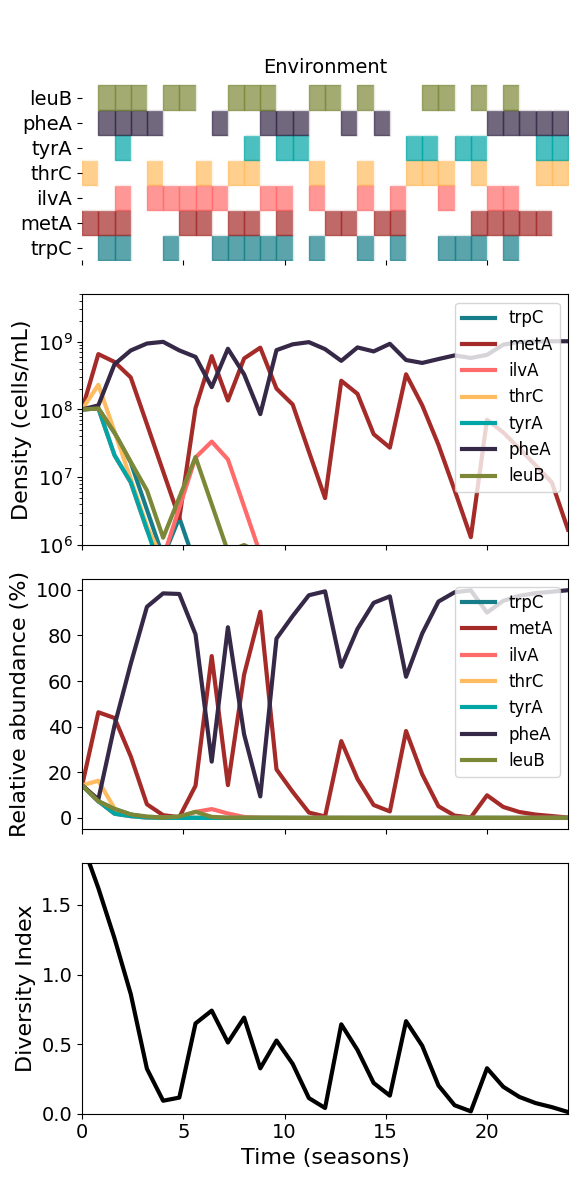

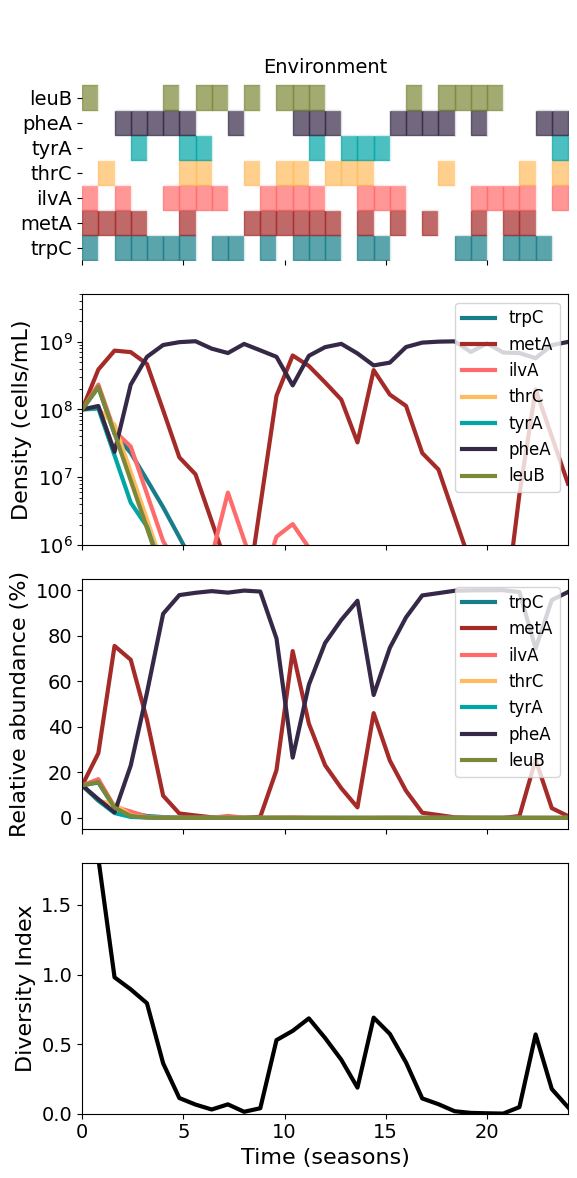

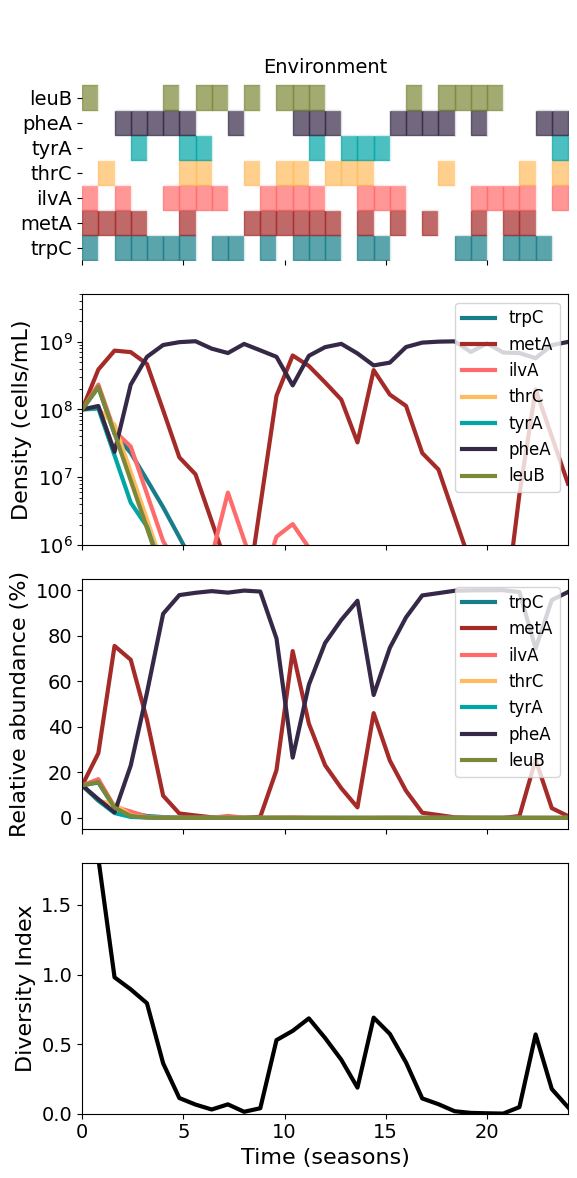

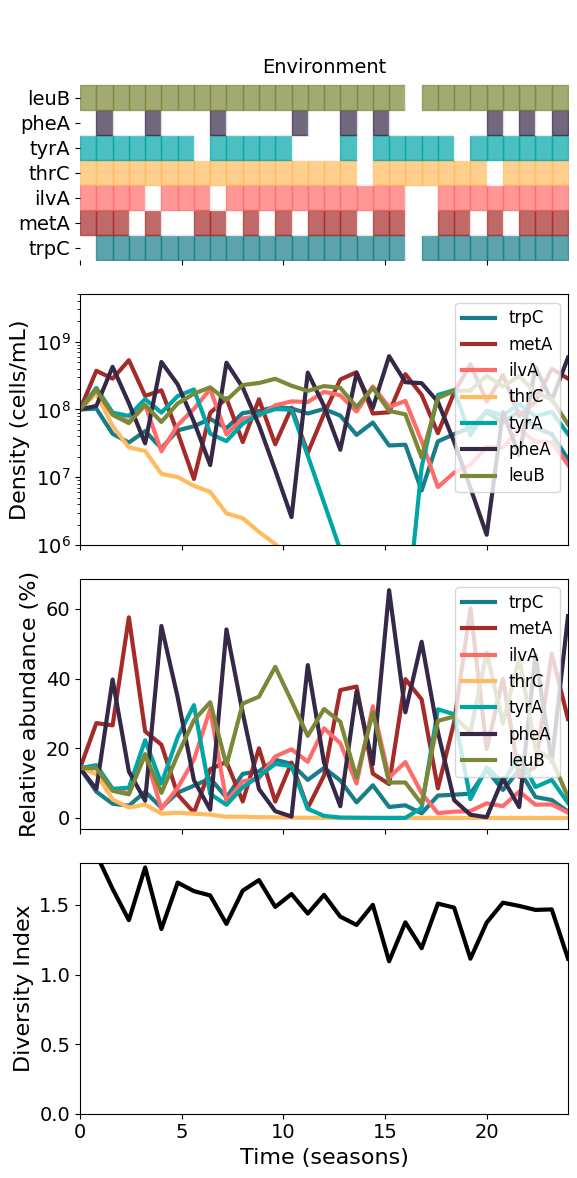

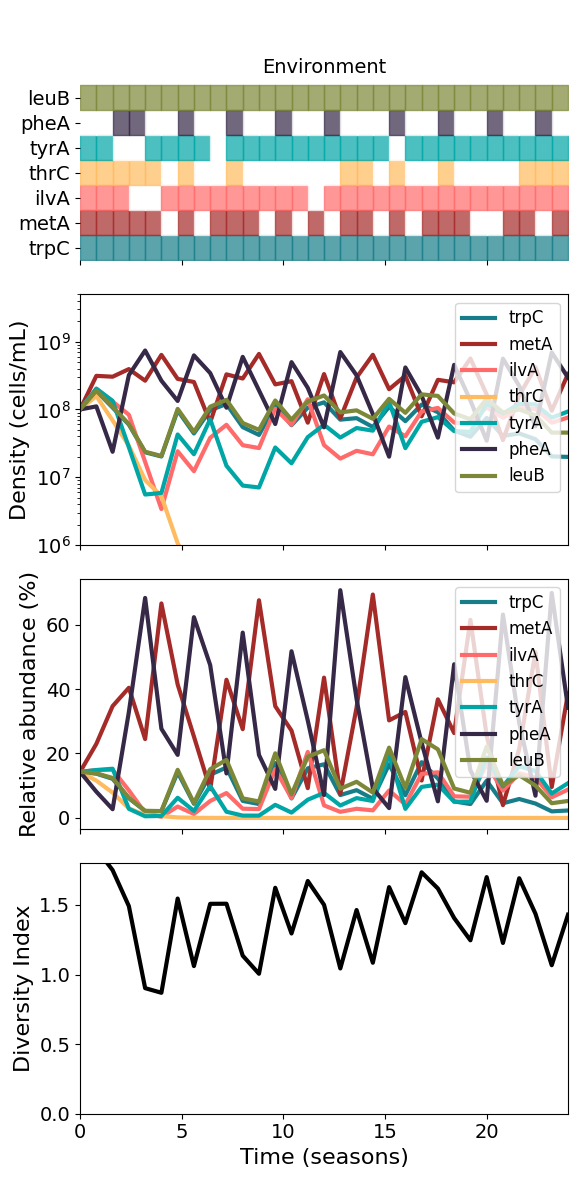

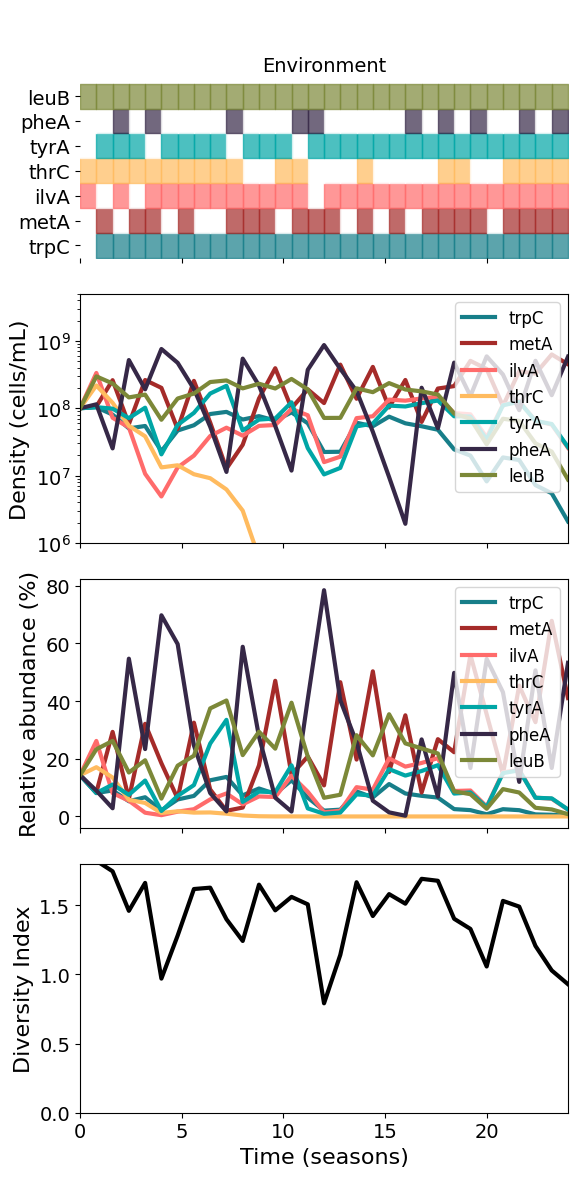

In [61]:
plot_selected_ga_generation_across_runs(
    runs_path=runs_path,
    num_ga_runs=num_ga_runs,
    strains_parameters=strains_parameters,
    u0=u0,
    T=T,
    num_days=N,
    mode="first"
)


plot_selected_ga_generation_across_runs(
    runs_path=runs_path,
    num_ga_runs=num_ga_runs,
    strains_parameters=strains_parameters,
    u0=u0,
    T=T,
    num_days=N,
    mode="last"
)


Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-ga-generations.pdf


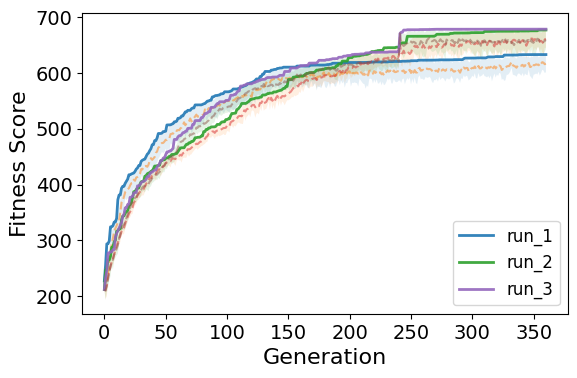

In [62]:
def plot_fitness_evolution_multiple_runs(
    runs_path,
    num_ga_runs,
    show_mean=True,
    show_std=True,
    show_labels=True
):
    plt.figure(figsize=(6,4))

    for run_id in range(1, num_ga_runs + 1):
        run_path = runs_path / f"ga_{run_id}"

        if not run_path.exists():
            print(f"Skipping missing folder: {run_path}")
            continue

        saved_generations = get_saved_generations(run_path)
        if len(saved_generations) == 0:
            print(f"Skipping empty run: {run_path}")
            continue

        best_fitness = []
        mean_fitness = []
        std_fitness = []
        generations = []

        for gen in saved_generations:
            checkpoint = load_ga_checkpoint(run_path, gen)

            generations.append(gen)
            best_fitness.append(checkpoint.get("best_fitness", np.nan))
            mean_fitness.append(checkpoint.get("mean_fitness", np.nan))
            std_fitness.append(checkpoint.get("std_fitness", np.nan))

        generations = np.array(generations)
        best_fitness = np.array(best_fitness, dtype=float)
        mean_fitness = np.array(mean_fitness, dtype=float)
        std_fitness = np.array(std_fitness, dtype=float)

        label = f"run_{run_id}" if show_labels else None

        plt.plot(
            generations,
            best_fitness,
            linewidth=2,
            alpha=0.9,
            label=label
        )

        if show_mean:
            plt.plot(
                generations,
                mean_fitness,
                linestyle="--",
                alpha=0.5
            )

        if show_std:
            plt.fill_between(
                generations,
                mean_fitness - std_fitness,
                mean_fitness + std_fitness,
                alpha=0.12
            )

    plt.xlabel("Generation", fontsize=16)
    plt.ylabel("Fitness Score", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(False)

    if show_labels:
        plt.legend(fontsize=12)

    plt.tight_layout()
    #plt.show()


plot_fitness_evolution_multiple_runs(
    runs_path=runs_path,
    num_ga_runs=num_ga_runs
)

outfile = figures_path / f"model-ga-generations.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

___
## Pairwise feedback

In [63]:
def simulate_feedback_pair(T, N, u0, strains, Amax, Amin, target_proportion):
    num_strains = len(strains)

    environmental_conditions = []
    ncycles = N
    u0_pop = u0.copy()
    results = []
    resultsT = []
    tdone = []

    for i in range(ncycles):
        initial_conditions = {'Time': i * T, 'S': u0_pop[0]}

        for j in range(num_strains):
            initial_conditions[f'A_{j+1}'] = u0_pop[j+1]
            initial_conditions[f'X_{j+1}'] = u0_pop[num_strains+j+1]

        results.append(initial_conditions)

        p = [strain['parameters'] for strain in strains]

        day_df = simulate_multistrain(T, u0_pop, p)
        day_df['Time'] = day_df['Time'] + i*T

        relative_proportion = calculate_relative_proportion(day_df)
        final_freqs = [
            relative_proportion.iloc[-1][f'X_{j+1}']
            for j in range(num_strains)
        ]

        next_aa_concentrations = [0] * num_strains

        if final_freqs[0] < target_proportion:
            next_aa_concentrations[0] = Amax
            next_aa_concentrations[1] = Amin
        else:
            next_aa_concentrations[0] = Amin
            next_aa_concentrations[1] = Amax

        environmental_conditions.append(next_aa_concentrations.copy())

        u0_pop = [
            S0,
            *next_aa_concentrations,
            *[delta * day_df.iloc[-1][f'X_{j+1}'] for j in range(num_strains)]
        ]

        for _, row in day_df.iterrows():
            cycle_result = {'Time': row['Time'], 'S': row['S']}

            for j in range(num_strains):
                cycle_result[f'A_{j+1}'] = row[f'A_{j+1}']
                cycle_result[f'X_{j+1}'] = row[f'X_{j+1}']

            results.append(cycle_result)

            if row['Time'] % 24 == 0 and row['Time'] not in tdone:
                cycle_resultT = {'Time': row['Time'], 'S': row['S']}

                for j in range(num_strains):
                    cycle_resultT[f'A_{j+1}'] = row[f'A_{j+1}']
                    cycle_resultT[f'X_{j+1}'] = row[f'X_{j+1}']

                resultsT.append(cycle_resultT)
                tdone.append(row['Time'])

    return pd.DataFrame(results), pd.DataFrame(resultsT), environmental_conditions

In [64]:
def simulate_feedback_multi(T, N, u0, strains, Amax, Amin, S0, delta, active_indices=None):
    environmental_conditions = []
    num_strains = len(strains)

    if active_indices is None:
        active_indices = list(range(num_strains))

    u0_pop = u0.copy()
    results = []
    resultsT = []
    tdone = []

    for cycle in range(N):
        initial_conditions = {'Time': cycle * T, 'S': u0_pop[0]}
        for j in range(num_strains):
            initial_conditions[f'A_{j+1}'] = u0_pop[j+1]
            initial_conditions[f'X_{j+1}'] = u0_pop[num_strains+j+1]
        results.append(initial_conditions)

        p = [strain['parameters'] for strain in strains]
        day_df = simulate_multistrain(T, u0_pop, p)
        day_df['Time'] = day_df['Time'] + cycle * T

        relative_proportion = calculate_relative_proportion(day_df)
        final_freqs = [relative_proportion.iloc[-1][f'X_{j+1}'] for j in range(num_strains)]

        # choose winner only among active strains
        max_density_index = max(active_indices, key=lambda j: final_freqs[j])

        next_aa_concentrations = [Amax] * num_strains
        next_aa_concentrations[max_density_index] = Amin

        environmental_conditions.append(next_aa_concentrations.copy())

        u0_pop = [
            S0,
            *next_aa_concentrations,
            *[delta * day_df.iloc[-1][f'X_{j+1}'] for j in range(num_strains)]
        ]

        for _, row in day_df.iterrows():
            cycle_result = {'Time': row['Time'], 'S': row['S']}
            for j in range(num_strains):
                cycle_result[f'A_{j+1}'] = row[f'A_{j+1}']
                cycle_result[f'X_{j+1}'] = row[f'X_{j+1}']
            results.append(cycle_result)

            if row['Time'] % 24 == 0 and row['Time'] not in tdone:
                cycle_resultT = {'Time': row['Time'], 'S': row['S']}
                for j in range(num_strains):
                    cycle_resultT[f'A_{j+1}'] = row[f'A_{j+1}']
                    cycle_resultT[f'X_{j+1}'] = row[f'X_{j+1}']
                resultsT.append(cycle_resultT)
                tdone.append(row['Time'])

    return pd.DataFrame(results), pd.DataFrame(resultsT), environmental_conditions

### Targeted control

In [65]:
def simulate_pairwise_feedback(
    strains_parameters,
    S0,
    Amax,
    Amin,
    B0,
    T,
    N,
    target
):
    pairwise_feedback_results = {}
    final_proportions = {}

    for pair_parameters in itertools.combinations(strains_parameters, 2):

        strain_names = [strain["name"] for strain in pair_parameters]
        pair_label = f"{strain_names[0][-4:]}_{strain_names[1][-4:]}"

        print(f"\n=== Pair: {pair_label} ===")
        print(strain_names)

        num_pair_strains = len(pair_parameters)

        u0_pair = [S0] + [Amax] * num_pair_strains + [B0] * num_pair_strains

        results_feedback_df, resultsT_feedback_df, feedback_environment = simulate_feedback_pair(
            T,
            N,
            u0_pair,
            pair_parameters,
            Amax,
            Amin,
            target
        )

        relative_proportion_feedback = calculate_relative_proportion(results_feedback_df)
        endpoint_relative_proportion_feedback = relative_proportion_feedback.iloc[-1]

        final_proportions[tuple(strain_names)] = endpoint_relative_proportion_feedback

        pairwise_feedback_results[pair_label] = {
            "pair_parameters": pair_parameters,
            "strain_names": strain_names,
            "results_df": results_feedback_df,
            "resultsT_df": resultsT_feedback_df,
            "relative_proportion_df": relative_proportion_feedback,
            "endpoint_relative_proportion": endpoint_relative_proportion_feedback,
            "environment": feedback_environment,
            "target": target,
        }

    return pairwise_feedback_results, final_proportions

In [66]:
def plot_pairwise_feedback_simulations(
    pairwise_feedback_results,
    N,
    figures_path=None,
    target=None
):
    for pair_label, record in pairwise_feedback_results.items():
        pair_parameters = record["pair_parameters"]
        resultsT_feedback_df = record["resultsT_df"]
        feedback_environment = record["environment"]

        plot_simulation(
            pair_parameters,
            resultsT_feedback_df,
            N,
            feedback_environment
        )

        if figures_path is not None:
            this_target = record.get("target", target)
            outfile = figures_path / f"model-feedback-pairwise-simulation-target{this_target}-{pair_label}.pdf"
            print(f"Exporting to {outfile}")
            plt.savefig(outfile, dpi=300, bbox_inches="tight")

In [67]:
def plot_pairwise_feedback_mean_frequencies(
    pairwise_feedback_results,
    strain_color_map,
    target=None,
    figures_path=None
):
    average_proportions = {}

    for pair_label, record in pairwise_feedback_results.items():
        rel = calculate_relative_proportion(record["resultsT_df"])

        # Mean endpoint frequency across transfer timepoints
        avg_freq = rel.mean(axis=0)
        average_proportions[pair_label] = avg_freq

    pair_labels = list(average_proportions.keys())

    plt.figure(figsize=(7, 3))
    r = np.arange(len(pair_labels))
    bar_width = 0.5

    used_labels = set()

    for idx, pair_label in enumerate(pair_labels):
        record = pairwise_feedback_results[pair_label]
        strain_names = record["strain_names"]
        avg_freq = average_proportions[pair_label]

        bottom = 0

        for j, strain_name in enumerate(strain_names):
            strain_label = strain_name[-4:]
            value = avg_freq[f"X_{j+1}"]

            label = strain_label if strain_label not in used_labels else None
            used_labels.add(strain_label)

            plt.bar(
                r[idx],
                value,
                bottom=bottom,
                width=bar_width,
                color=strain_color_map.get(strain_label, "gray"),
                edgecolor="grey",
                label=label
            )

            bottom += value

    if target is not None:
        plt.axhline(y=target, linestyle="--", color="black", linewidth=1)

    plt.ylabel("Mean freq. (%)", fontsize=16)
    plt.xticks(
        r,
        [label.replace("_", " vs ") for label in pair_labels],
        rotation="vertical",
        fontsize=12
    )
    plt.ylim(0, 100)

    if len(used_labels) > 0:
        plt.legend(
            title="Strain",
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

    plt.tight_layout()

    if figures_path is not None:
        outfile = figures_path / f"model-feedback-pairwise-mean-frequency-target{target}.pdf"
        print(f"Exporting to {outfile}")
        plt.savefig(outfile, dpi=300, bbox_inches="tight")

    plt.show()

In [68]:
target = 20

pairwise_feedback_results, final_proportions = simulate_pairwise_feedback(
    strains_parameters=strains_parameters,
    S0=S0,
    Amax=Amax,
    Amin=Amin,
    B0=B0,
    T=T,
    N=N,
    target=target
)

plot_pairwise_feedback_simulations(
    pairwise_feedback_results,
    N=N,
    figures_path=figures_path,
    target=target
)

plot_pairwise_feedback_mean_frequencies(
    pairwise_feedback_results,
    strain_color_map=strain_color_map,
    target=target,
    figures_path=figures_path
)

Output hidden; open in https://colab.research.google.com to view.

In [69]:
target = 80

pairwise_feedback_results, final_proportions = simulate_pairwise_feedback(
    strains_parameters=strains_parameters,
    S0=S0,
    Amax=Amax,
    Amin=Amin,
    B0=B0,
    T=T,
    N=N,
    target=target
)

plot_pairwise_feedback_simulations(
    pairwise_feedback_results,
    N=N,
    figures_path=figures_path,
    target=target
)

plot_pairwise_feedback_mean_frequencies(
    pairwise_feedback_results,
    strain_color_map=strain_color_map,
    target=target,
    figures_path=figures_path
)

Output hidden; open in https://colab.research.google.com to view.

## Multistrain Feedback

In [70]:
feedback_summary_path = feedback_path / "summary.pkl"

results_feedback_df, resultsT_feedback_df, feedback_environment = simulate_feedback_multi(
    T, N, u0, strains_parameters, Amax, Amin, S0, delta
)

add_reference(
    references=references,
    name="feedback",
    environment=feedback_environment,
    results_df=results_feedback_df,
    resultsT_df=resultsT_feedback_df
)

feedback_summary_df = build_reference_summary(references)
feedback_summary_df.to_pickle(feedback_summary_path)

Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-feedback_simulation.pdf


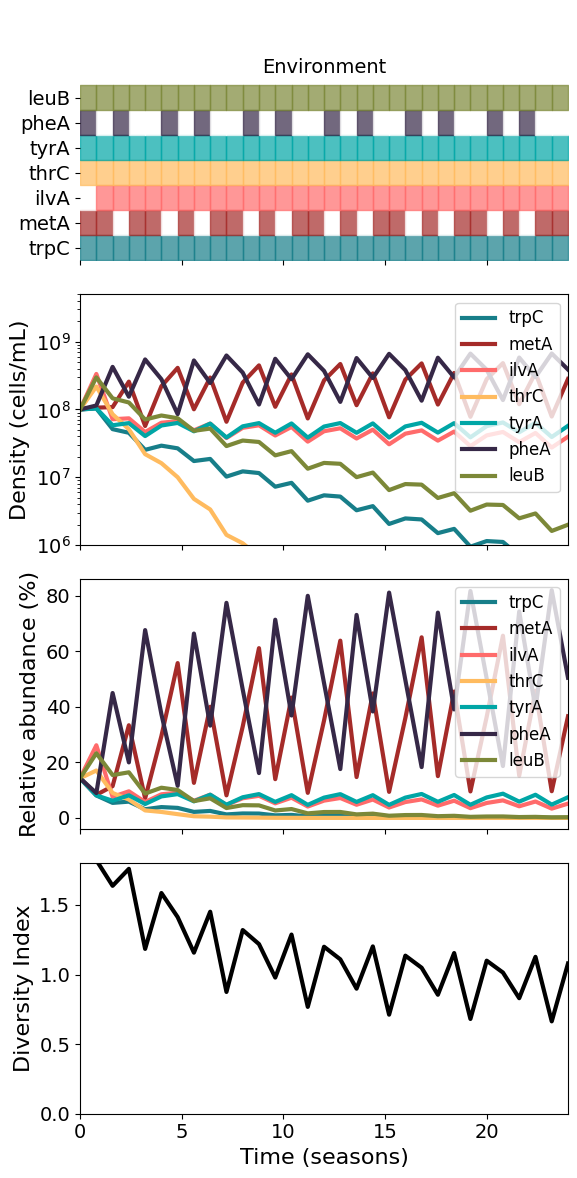

In [71]:

# Plot the simulation results
plot_simulation(strains_parameters, resultsT_feedback_df, N, feedback_environment)
outfile = figures_path / f"model-feedback_simulation.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

## Feedback: combinatorics


In [72]:
subset_feedback_references = {}

num_strains = len(strains_parameters)
all_indices = list(range(num_strains))

total_subsets = sum([
    len(list(combinations(all_indices, k)))
    for k in range(0, num_strains + 1)
])
counter = 0

for subset_size in range(1, num_strains + 1):
    print(f"\n=== Subset size: {subset_size} ===")

    for active_indices in combinations(all_indices, subset_size):
        counter += 1
        active_indices = list(active_indices)

        active_strains = [strains_parameters[j]["name"] for j in active_indices]
        subset_label = "_".join([s[-4:] for s in active_strains])
        ref_name = f"feedback_subset_{subset_size}_{subset_label}"

        print(f"\n[{counter}/{total_subsets}] {ref_name}")
        print(f"Active strains: {active_strains}")

        u0_subset = make_subset_u0(
            u0=u0,
            active_indices=active_indices,
            num_strains=num_strains
        )

        initial_pop = u0_subset[num_strains+1:]
        print(f"Initial populations: {initial_pop}")

        results_subset_df, resultsT_subset_df, feedback_subset_environment = simulate_feedback_multi(
            T=T,
            N=N,
            u0=u0_subset,
            strains=strains_parameters,
            Amax=Amax,
            Amin=Amin,
            S0=S0,
            delta=delta,
            active_indices=active_indices
        )

        add_reference(
            references=subset_feedback_references,
            name=ref_name,
            environment=feedback_subset_environment,
            results_df=results_subset_df,
            resultsT_df=resultsT_subset_df,
            extra={
                "subset_size": subset_size,
                "active_indices": active_indices,
                "active_strains": active_strains,
            }
        )


=== Subset size: 1 ===

[1/128] feedback_subset_1_trpC
Active strains: ['M9_1X_trpC']
Initial populations: [100000000.0, 0, 0, 0, 0, 0, 0]

[2/128] feedback_subset_1_metA
Active strains: ['M9_1X_metA']
Initial populations: [0, 100000000.0, 0, 0, 0, 0, 0]

[3/128] feedback_subset_1_ilvA
Active strains: ['M9_1X_ilvA']
Initial populations: [0, 0, 100000000.0, 0, 0, 0, 0]

[4/128] feedback_subset_1_thrC
Active strains: ['M9_1X_thrC']
Initial populations: [0, 0, 0, 100000000.0, 0, 0, 0]

[5/128] feedback_subset_1_tyrA
Active strains: ['M9_1X_tyrA']
Initial populations: [0, 0, 0, 0, 100000000.0, 0, 0]

[6/128] feedback_subset_1_pheA
Active strains: ['M9_1X_pheA']
Initial populations: [0, 0, 0, 0, 0, 100000000.0, 0]

[7/128] feedback_subset_1_leuB
Active strains: ['M9_1X_leuB']
Initial populations: [0, 0, 0, 0, 0, 0, 100000000.0]

=== Subset size: 2 ===

[8/128] feedback_subset_2_trpC_metA
Active strains: ['M9_1X_trpC', 'M9_1X_metA']
Initial populations: [100000000.0, 100000000.0, 0, 0, 0, 0

In [73]:
subset_feedback_summary_df = build_reference_summary(subset_feedback_references)

subset_feedback_summary_path = feedback_path / "subset_feedback_summary.pkl"
subset_feedback_summary_df.to_pickle(subset_feedback_summary_path)

print(f"Saved subset feedback summary to {subset_feedback_summary_path}")

Saved subset feedback summary to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/runs_local/feedback/subset_feedback_summary.pkl


## Comparison between strategies

In [74]:
def get_strategy_type(name):
    if name.startswith("constant"):
        return "constant"
    elif name.startswith("optimal"):
        return "optimal"
    elif name.startswith("feedback"):
        return "feedback"
    else:
        return "other"

In [75]:
def plot_hist_with_reference_df(
    data,
    xlabel,
    title,
    reference_df,
    value_col,
    bins=30,
    log_x=False
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt



    data = pd.Series(data).dropna()

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.hist(
        data,
        bins=bins,
        color=REGIME_COLORS["random"],
        alpha=0.85,
        edgecolor="white",
        linewidth=0.6
    )

    ref_df = reference_df.copy()

    # Average constant treatments
    constant_df = ref_df[ref_df["strategy"].apply(get_strategy_type) == "constant"]

    if len(constant_df) > 0:
        constant_value = constant_df[value_col].dropna().mean()

        ax.axvline(
            constant_value,
            color=REGIME_COLORS["constant"],
            linestyle="--",
            linewidth=2.5,
            label="Constant (mean)"
        )

        print(f"Constant mean: {constant_value:.4g}")


    # Median of random distribution
    median_value = data.median()
    ax.axvline(
        median_value,
        color=REGIME_COLORS["median"],
        linestyle="-",
        linewidth=2,
        label=f"Random (median)"
    )

    print(f"Random median: {median_value:.4g}")



    # Feedback
    feedback_df = ref_df[ref_df["strategy"].apply(get_strategy_type) == "feedback"]

    if len(feedback_df) > 0:
        feedback_value = feedback_df[value_col].dropna().mean()

        ax.axvline(
            feedback_value,
            color=REGIME_COLORS["feedback"],
            linestyle="-",
            linewidth=2.5,
            label="Feedback"
        )

        print(f"Feedback: {feedback_value:.4g}")

    # Best optimal only
    optimal_df = ref_df[ref_df["strategy"].apply(get_strategy_type) == "optimal"]

    if len(optimal_df) > 0:
        best_optimal_row = optimal_df.loc[optimal_df[value_col].idxmax()]
        optimal_value = best_optimal_row[value_col]

        ax.axvline(
            optimal_value,
            color=REGIME_COLORS["optimal"],
            linestyle="-",
            linewidth=2.5,
            label="Best optimized"
        )

        print(f"Best optimal: {optimal_value:.4g}")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of simulations")
    ax.set_title(title)

    if log_x:
        ax.set_xscale("log")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    plt.tight_layout()
    #plt.show()

Constant mean: 177.1
Random median: 337
Feedback: 833
Best optimal: 1066
Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-random-histogram-shannon.pdf


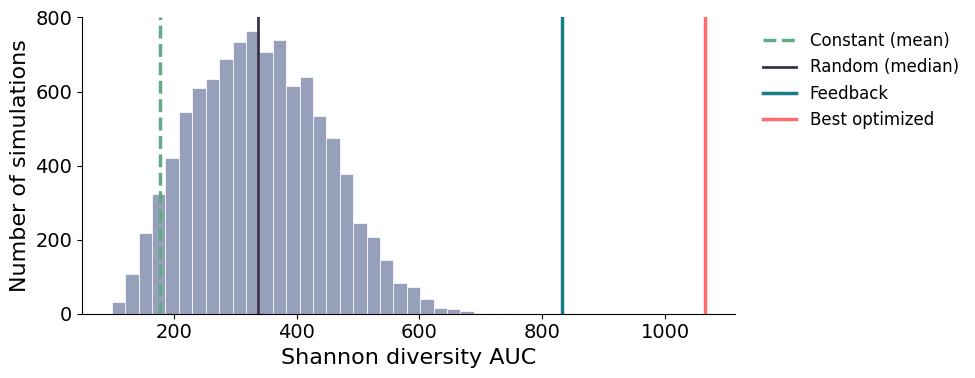

In [76]:
reference_summary_df = build_reference_summary(references)

plot_hist_with_reference_df(
    random_summary_df["shannon_auc"],
    xlabel="Shannon diversity AUC",
    title="",
    reference_df=reference_summary_df,
    value_col="diversity_auc",
    log_x=False
)
outfile = figures_path / f"model-random-histogram-shannon.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

Constant mean: 6.575e+11
Random median: 5.353e+11
Feedback: 5.718e+11
Best optimal: 6.277e+11
Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-random-histogram-density.pdf


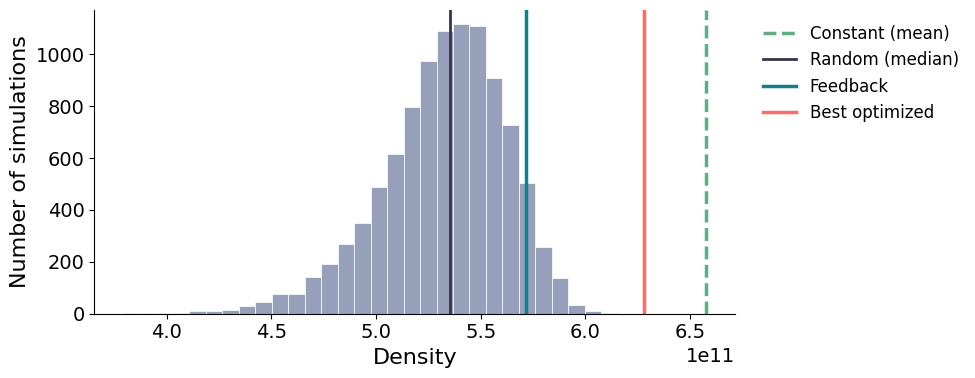

In [77]:
plot_hist_with_reference_df(
    random_summary_df["density_auc"],
    xlabel="Density",
    title="",
    reference_df=reference_summary_df,
    value_col="density_auc",
    log_x=False
)
outfile = figures_path / f"model-random-histogram-density.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

In [78]:
def compute_reference_stats(summary_df, reference_df):
    results = []

    mapping = {
        "fitness_value": "fitness_value",
        "diversity_auc": "shannon_auc",
        "density_auc": "density_auc",
        "endpoint_shannon": "endpoint_shannon"
    }

    for _, row in reference_df.iterrows():
        strategy = row["strategy"]

        for ref_key, rand_col in mapping.items():
            ref_val = row.get(ref_key, np.nan)

            if pd.isna(ref_val):
                continue

            values = summary_df[rand_col].dropna()

            mean = values.mean()
            std = values.std()

            percentile = (values <= ref_val).mean()

            # one-sided empirical p-value (better than random)
            p_value = 1 - percentile

            results.append({
                "strategy": strategy,
                "metric": ref_key,
                "value": ref_val,
                "random_mean": mean,
                "random_std": std,
                "percentile": percentile,
                "p_value": p_value
            })

    return pd.DataFrame(results)

stats_df = compute_reference_stats(random_summary_df, reference_summary_df)
print(stats_df)

          strategy            metric         value   random_mean  \
0    constant_0.10     fitness_value  1.082746e+02  2.641523e+02   
1    constant_0.10     diversity_auc  1.578681e+02  3.413782e+02   
2    constant_0.10       density_auc  3.229334e+11  5.320472e+11   
3    constant_0.10  endpoint_shannon  3.998782e-09  1.756924e-01   
4    constant_0.20     fitness_value  1.266871e+02  2.641523e+02   
..             ...               ...           ...           ...   
491      optimal_3  endpoint_shannon  9.292834e-01  1.756924e-01   
492       feedback     fitness_value  6.677878e+02  2.641523e+02   
493       feedback     diversity_auc  8.329670e+02  3.413782e+02   
494       feedback       density_auc  5.717779e+11  5.320472e+11   
495       feedback  endpoint_shannon  1.079418e+00  1.756924e-01   

       random_std  percentile  p_value  
0    6.999627e+01      0.0009   0.9991  
1    1.066202e+02      0.0281   0.9719  
2    3.000681e+10      0.0000   1.0000  
3    2.397194e-01  

In [79]:
def print_comparisons(stats_df):
    print("\n=== Statistical Comparisons ===\n")

    for strategy in stats_df["strategy"].unique():
        print(f"\n--- {strategy} ---")

        sub = stats_df[stats_df["strategy"] == strategy]

        for _, row in sub.iterrows():
            print(
                f"{row['metric']}: "
                f"{row['value']:.2f} "
                f"(random: {row['random_mean']:.2f} ± {row['random_std']:.2f}) | "
                f"{row['percentile']*100:.1f}th percentile | "
                f"p ≈ {row['p_value']:.3f}"
            )
print_comparisons(stats_df)


=== Statistical Comparisons ===


--- constant_0.10 ---
fitness_value: 108.27 (random: 264.15 ± 70.00) | 0.1th percentile | p ≈ 0.999
diversity_auc: 157.87 (random: 341.38 ± 106.62) | 2.8th percentile | p ≈ 0.972
density_auc: 322933362051.07 (random: 532047205086.01 ± 30006809796.80) | 0.0th percentile | p ≈ 1.000
endpoint_shannon: 0.00 (random: 0.18 ± 0.24) | 0.1th percentile | p ≈ 0.999

--- constant_0.20 ---
fitness_value: 126.69 (random: 264.15 ± 70.00) | 0.9th percentile | p ≈ 0.991
diversity_auc: 163.51 (random: 341.38 ± 106.62) | 3.5th percentile | p ≈ 0.965
density_auc: 423839305412.62 (random: 532047205086.01 ± 30006809796.80) | 0.3th percentile | p ≈ 0.997
endpoint_shannon: 0.00 (random: 0.18 ± 0.24) | 2.2th percentile | p ≈ 0.978

--- constant_0.30 ---
fitness_value: 139.77 (random: 264.15 ± 70.00) | 2.4th percentile | p ≈ 0.976
diversity_auc: 171.52 (random: 341.38 ± 106.62) | 4.5th percentile | p ≈ 0.955
density_auc: 468224793149.82 (random: 532047205086.01 ± 30006809796.

In [80]:
def plot_subset_metric_feedback_vs_constant(
    subset_feedback_summary_df,
    subset_constant_summary_df,
    metric="fitness_value"
):
    import numpy as np
    import matplotlib.pyplot as plt

    fb = subset_feedback_summary_df.dropna(subset=[metric])
    const = subset_constant_summary_df.dropna(subset=[metric])

    fb_summary = (
        fb.groupby("subset_size")[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    const_summary = (
        const.groupby("subset_size")[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    # SEM
    fb_summary["sem"] = fb_summary["std"] / np.sqrt(fb_summary["count"])
    const_summary["sem"] = (
        const_summary["std"] / np.sqrt(const_summary["count"])
    )

    fig, ax = plt.subplots(figsize=(6, 4))

    # Raw points
    ax.scatter(
        fb["subset_size"],
        fb[metric],
        alpha=0.18,
        color=REGIME_COLORS["feedback"]
    )

    ax.scatter(
        const["subset_size"],
        const[metric],
        alpha=0.18,
        color=REGIME_COLORS["constant"]
    )

    # Mean ± SEM
    ax.errorbar(
        fb_summary["subset_size"],
        fb_summary["mean"],
        yerr=fb_summary["sem"],
        fmt="o-",
        capsize=4,
        linewidth=2,
        color=REGIME_COLORS["feedback"],
        label="Feedback"
    )

    ax.errorbar(
        const_summary["subset_size"],
        const_summary["mean"],
        yerr=const_summary["sem"],
        fmt="s-",
        capsize=4,
        linewidth=2,
        color=REGIME_COLORS["constant"],
        label="Constant"
    )

    ax.set_xlabel("Community size")
    ax.set_ylabel(format_metric_label(metric))

    ax.set_xticks(
        sorted(
            set(fb["subset_size"]).union(
                set(const["subset_size"])
            )
        )
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    plt.tight_layout()
    #plt.show()

Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-comparison_fitness.pdf
Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-comparison_diversity.pdf
Exporting to /content/drive/MyDrive/SYNC_Projects/ProfileX/GIT/figures/model-comparison_density.pdf


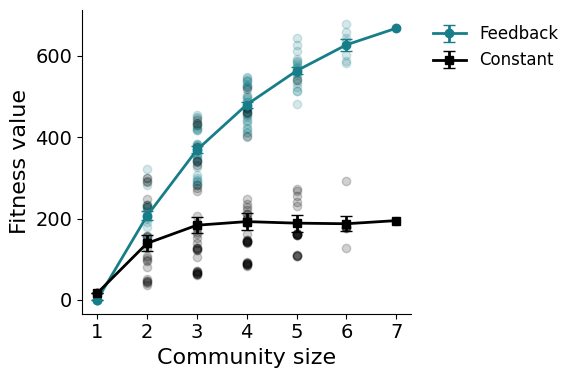

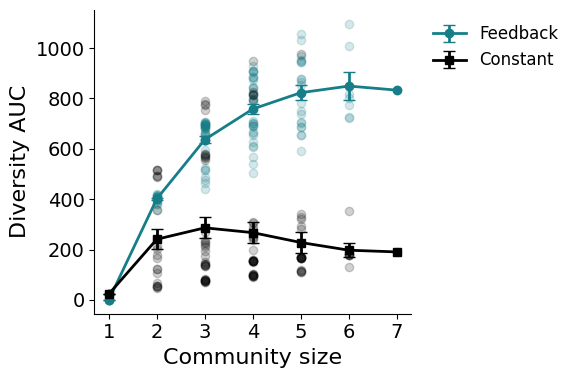

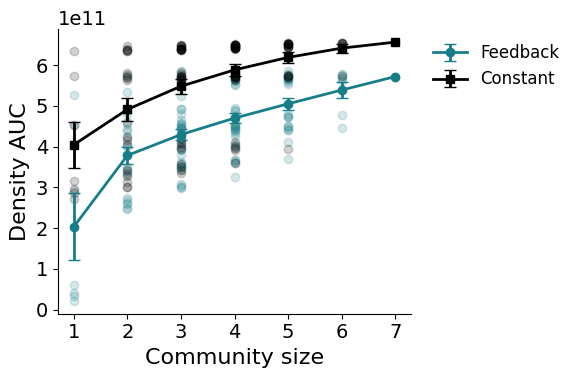

In [81]:
REGIME_COLORS = {
        "constant": "#000000",
        "feedback": "#177E89",
        "optimal": "#B63E36",
        "random": "#F3D9A7",
        "median": "#393349",
    }

plot_subset_metric_feedback_vs_constant(
    subset_feedback_summary_df,
    subset_constant_summary_df,
    metric="fitness_value"
)
outfile = figures_path / f"model-comparison_fitness.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300)

plot_subset_metric_feedback_vs_constant(
    subset_feedback_summary_df,
    subset_constant_summary_df,
    metric="diversity_auc"
)
outfile = figures_path / f"model-comparison_diversity.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300,)

plot_subset_metric_feedback_vs_constant(
    subset_feedback_summary_df,
    subset_constant_summary_df,
    metric="density_auc"
)
outfile = figures_path / f"model-comparison_density.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300)


